*[jump to Sharstry-Mattis](#cell2)
*[jump to Real space](#cell3)
*[jump to Exciton_magnon](#cell4)

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from scipy.optimize import curve_fit
# ---------- global style (journal-like) ----------
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}\usepackage{amsmath}",  # lighter than newtx
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "stix",
    "axes.labelsize": 10, "axes.titlesize": 10,  # Slightly smaller for PRB style
    "xtick.labelsize": 10, "ytick.labelsize": 10,  # Smaller tick labels
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,  # Add minor ticks
    "legend.frameon": False,  # No frame for cleaner look
    "legend.fontsize": 10,  # Smaller legend font
    "lines.linewidth": 1.2,  # Slightly thicker lines
})

# Shastry-Mattis Magnetic Polaron Theory

<a id="cell2"></a>

In [2]:
"""
Shastry-Mattis Magnetic Polaron Theory
Reproduces Figures 2, 3, 5 from Phys. Rev. B 24, 5340 (1981)

Theory of a single electron coupled to ferromagnetic spin background
with spin-flip processes and magnon emission/absorption.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

class MagneticPolaron:
    """
    Exact solution for magnetic polaron problem.
    
    Parameters from paper (in units of |J|=1):
    - J = ±1 (ferromagnetic +1, antiferromagnetic -1)
    - W = 10 (bandwidth)
    - w_m = 0.01 (max magnon energy)
    - s = 7/2 (localized spin)
    - gamma = 1 (Heisenberg limit)
    """
    
    def __init__(self, J, W=10.0, w_m=0.01, s=3.5, gamma=1.0):
        self.J = J
        self.W = W
        self.w_m = w_m
        self.s = s
        self.gamma = gamma
        
    def epsilon_k(self, k):
        """Parabolic electron band: ε_k = W k²"""
        return self.W * k**2
    
    def omega_q(self, q):
        """Parabolic magnon: ω_q = w_m q²"""
        return self.w_m * q**2
    
    def v_k(self, k, omega):
        """
        Shifted energy variable from Eq. (35):
        v_k = ω + Js/2 - (w_m/(w_m+W))ε_k
        """
        eps_k = self.epsilon_k(k)
        return omega + self.J*self.s/2.0 - (self.w_m/(self.w_m + self.W))*eps_k
    
    def compute_A(self, k, omega):
        """
        Compute A(k,ω) = A₁ + i A₂ from Eqs. (37-40)
        
        This is the key function that enters the self-energy.
        """
        v = self.v_k(k, omega)
        W_plus_wm = self.W + self.w_m
        
        if v < 0:
            # v_k < 0: Eqs. (39-40)
            abs_v = abs(v)
            sqrt_ratio = np.sqrt(abs_v / W_plus_wm)
            
            A1 = (3.0 / W_plus_wm) * (1.0 - sqrt_ratio * np.arctan(1.0/sqrt_ratio))
            A2 = 0.0  # θ(v_k) = 0 for v < 0
            
        else:
            # v_k > 0: Eqs. (40)
            sqrt_v = np.sqrt(v)
            sqrt_W = np.sqrt(W_plus_wm)
            
            # Handle log singularity carefully
            if v < W_plus_wm * 0.9999:  # avoid denominator → 0
                ratio = (sqrt_W + sqrt_v) / (sqrt_W - sqrt_v)
                A1 = (3.0 / W_plus_wm) * (1.0 - 0.5 * np.sqrt(v/W_plus_wm) * np.log(abs(ratio)))
            else:
                # Near singularity, use asymptotic form
                A1 = (3.0 / W_plus_wm) * (1.0 - 0.5 * np.sqrt(v/W_plus_wm) * 10.0)  # large value
            
            # Imaginary part from Eq. (38)
            A2 = (3.0 * np.pi / (2.0 * W_plus_wm**(3/2))) * sqrt_v
            
        return A1, A2
    
    def compute_self_energy(self, k, omega):
        """
        Compute self-energy Σ(k,ω) = Σ₁ + i Σ₂ from Eqs. (42-43)
        
        Σ₁ = Js γ² [(1 + J/2 A₁) / ((1 + J/2 A₁)² + (J²/4)A₂²) - 1]
        
        Σ₂ = -(J²s/2) γ² A₂ / ((1 + J/2 A₁)² + (J²/4)A₂²)
        """
        A1, A2 = self.compute_A(k, omega)
        
        # Common denominator
        term1 = 1.0 + (self.J/2.0)*A1
        term2 = (self.J**2 / 4.0) * A2**2
        denom = term1**2 + term2
        
        # Real part of self-energy
        Sigma1 = self.J * self.s * self.gamma**2 * (term1 / denom - 1.0)
        
        # Imaginary part of self-energy
        Sigma2 = -(self.J**2 * self.s / 2.0) * self.gamma**2 * (A2 / denom)
        
        return Sigma1, Sigma2
    
    def spectral_weight(self, k, omega, eta=1e-4):
        """
        Down-spin spectral weight from Eq. (45):
        
        ρ↓(k,ω) = (1/π) * η / [(η - Σ₂)² + (ω - ε_k - Js/2 - Σ₁)²]
        
        where η = 0⁺ is small positive number (broadening)
        """
        eps_k = self.epsilon_k(k)
        Sigma1, Sigma2 = self.compute_self_energy(k, omega)
        
        # Hartree energy
        E_hartree = eps_k + self.J * self.s / 2.0
        
        # Spectral function
        numerator = eta - Sigma2  # This should be positive
        denominator = (eta - Sigma2)**2 + (omega - E_hartree - Sigma1)**2
        
        rho = (1.0 / np.pi) * abs(numerator) / denominator
        
        return rho
    
    def density_of_states(self, omega, k_max=1.0, nk=100, eta=1e-4):
        """
        Total density of states: ρ(ω) = (1/N) Σ_k ρ(k,ω)
        
        Integrate over k in spherical approximation.
        """
        k_values = np.linspace(0, k_max, nk)
        
        dos = 0.0
        for k in k_values:
            if k == 0:
                weight = 0  # No states at k=0 in 3D
            else:
                weight = k**2  # 3D density of states ∝ k²
            dos += weight * self.spectral_weight(k, omega, eta)
        
        # Normalize
        dos = dos / np.sum(k_values**2) if np.sum(k_values**2) > 0 else dos
        
        return dos


def plot_figure_2():
    """
    Reproduce Figure 2: Spectral weight for k=0, J>0
    Shows the broad scattering peak near Hartree value and weak bound state above.
    """
    print("Generating Figure 2: J > 0, k = 0...")
    
    polaron = MagneticPolaron(J=+1.0, W=10.0, w_m=0.01, s=3.5, gamma=1.0)
    
    # Energy range
    # Hartree energy at k=0: E = 0 + J*s/2 = 1.75
    omega_values = np.linspace(-2.0, 10.0, 1000)
    
    k = 0.0
    rho_values = np.array([polaron.spectral_weight(k, omega, eta=0.02) for omega in omega_values])
    
    # Hartree prediction
    E_hartree = 0.0 + polaron.J * polaron.s / 2.0
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.plot(omega_values, rho_values, 'b-', linewidth=2, label='Exact')
    ax.axvline(E_hartree, color='red', linestyle='--', linewidth=2, label=f'Hartree: $\omega$ = {E_hartree:.2f}')
    
    # Mark bound state (should be above scattering continuum for J>0)
    # The bound state is where G⁻¹ = 0, which is hard to locate analytically
    # but should appear as a peak above the main continuum
    
    ax.set_xlabel('$\omega$/J+s/2', fontsize=14)
    ax.set_ylabel('$\rho_{d}$(k=0, $\omega$)', fontsize=14)
    ax.set_title('Down-Spin Spectral Weight: J > 0, k = 0', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 10)
    
    plt.tight_layout()
    plt.savefig('shastry_mattis_fig2.png', dpi=150, bbox_inches='tight')
    print("Saved: shastry_mattis_fig2.png")
    
    return fig


def plot_figure_3():
    """
    Reproduce Figure 3: Spectral weight for J>0 at ε_k = 0, J, 3J
    Shows how linewidth increases with increasing k (more phase space for magnon emission)
    """
    print("Generating Figure 3: J > 0, multiple k values...")
    
    polaron = MagneticPolaron(J=+1.0, W=10.0, w_m=0.01, s=3.5, gamma=1.0)
    
    # For ε_k = Wk², we need k = sqrt(ε_k/W)
    epsilon_values = [0.0, 1.0, 3.0]  # ε_k = 0, J, 3J
    k_values = [np.sqrt(eps/polaron.W) for eps in epsilon_values]
    
    omega_values = np.linspace(-2.0, 10.0, 1000)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    colors = ['blue', 'green', 'red']
    for i, (k, eps) in enumerate(zip(k_values, epsilon_values)):
        rho_values = np.array([polaron.spectral_weight(k, omega, eta=0.02) for omega in omega_values])
        
        E_hartree = eps + polaron.J * polaron.s / 2.0
        
        ax.plot(omega_values, rho_values, color=colors[i], linewidth=2, 
                label=f'$\epsilon_k$ = {eps:.1f}J')
        ax.axvline(E_hartree, color=colors[i], linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('$\omega$/J', fontsize=14)
    ax.set_ylabel('$\rho_{d}$(k, $\omega$)', fontsize=14)
    ax.set_title('Down-Spin Spectral Weight: J > 0, Various k', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 10)
    
    plt.tight_layout()
    plt.savefig('shastry_mattis_fig3.png', dpi=150, bbox_inches='tight')
    print("Saved: shastry_mattis_fig3.png")
    
    return fig


def plot_figure_5():
    """
    Reproduce Figure 5: Spectral weight for k=0, J<0 (antiferromagnetic)
    Shows sharp bound state (polaron) below scattering continuum.
    """
    print("Generating Figure 5: J < 0, k = 0 (polaron state)...")
    
    polaron = MagneticPolaron(J=-1.0, W=10.0, w_m=0.01, s=3.5, gamma=1.0)
    
    # Energy range
    # Hartree energy at k=0: E = 0 - J*s/2 = -1.75
    omega_values = np.linspace(-4.0, 5.0, 1000)
    
    k = 0.0
    rho_values = np.array([polaron.spectral_weight(k, omega, eta=0.005) for omega in omega_values])
    
    # Hartree prediction
    E_hartree = 0.0 + polaron.J * polaron.s / 2.0  # = -1.75
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.plot(omega_values, rho_values, 'b-', linewidth=2, label='Exact (Polaron)')
    ax.axvline(E_hartree, color='red', linestyle='--', linewidth=2, 
               label=f'Hartree: $\omega$ = {E_hartree:.2f}')
    
    # The bound state should be at lower energy than Hartree (binding energy ≈ 1.5 J²/W from Eq. 49)
    binding_energy = 1.5 * polaron.J**2 / polaron.W
    E_bound_estimate = E_hartree - binding_energy
    ax.axvline(E_bound_estimate, color='green', linestyle=':', linewidth=2,
               label=f'Bound state est: $\omega$ = {E_bound_estimate:.2f}')
    
    ax.set_xlabel('$\omega$/J', fontsize=14)
    ax.set_ylabel('$\rho_{d}$(k=0, $\omega$)', fontsize=14)
    ax.set_title('Down-Spin Spectral Weight: J < 0 (Polaron), k = 0', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 5)
    
    
    plt.tight_layout()
    plt.savefig('shastry_mattis_fig5.png', dpi=150, bbox_inches='tight')
    print("Saved: shastry_mattis_fig5.png")
    
    return fig


def plot_combined_comparison():
    """
    Create a combined figure showing all three cases side by side.
    """
    print("Generating combined comparison figure...")
    
    fig = plt.figure(figsize=(15, 5))
    gs = GridSpec(1, 3, figure=fig)
    
    # Figure 2: J > 0, k = 0
    ax1 = fig.add_subplot(gs[0, 0])
    polaron_ferro = MagneticPolaron(J=+1.0, W=10.0, w_m=0.01, s=3.5, gamma=1.0)
    omega_vals = np.linspace(-2, 10, 500)
    rho_ferro = [polaron_ferro.spectral_weight(0.0, omega, eta=0.02) for omega in omega_vals]
    ax1.plot(omega_vals, rho_ferro, 'b-', linewidth=2)
    ax1.axvline(polaron_ferro.J * polaron_ferro.s / 2, color='r', linestyle='--', label='Hartree')
    ax1.set_xlabel('$\omega$/J+s/2', fontsize=12)
    ax1.set_ylabel('$\rho_{d}$(k, $\omega$)', fontsize=12)
    ax1.set_title('(a) J > 0, k = 0\n(Ferromagnetic)', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Figure 3: J > 0, multiple k
    ax2 = fig.add_subplot(gs[0, 1])
    epsilon_values = [0.0, 1.0, 3.0]
    colors = ['blue', 'green', 'red']
    for eps, color in zip(epsilon_values, colors):
        k = np.sqrt(eps/polaron_ferro.W)
        rho_vals = [polaron_ferro.spectral_weight(k, omega, eta=0.02) for omega in omega_vals]
        ax2.plot(omega_vals, rho_vals, color=color, linewidth=2, label=f'$\epsilon$={eps:.1f}J')
    ax2.set_xlabel('$\omega$/J', fontsize=12)
    ax2.set_ylabel('$\rho_{d}$(k, $\omega$)', fontsize=12)
    ax2.set_title('(b) J > 0, various k\n(Linewidth increases with k)', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Figure 5: J < 0, k = 0
    ax3 = fig.add_subplot(gs[0, 2])
    polaron_afm = MagneticPolaron(J=-1.0, W=10.0, w_m=0.01, s=3.5, gamma=1.0)
    omega_vals_afm = np.linspace(-4, 5, 500)
    rho_afm = [polaron_afm.spectral_weight(0.0, omega, eta=0.005) for omega in omega_vals_afm]
    ax3.plot(omega_vals_afm, rho_afm, 'b-', linewidth=2)
    ax3.axvline(polaron_afm.J * polaron_afm.s / 2, color='r', linestyle='--', label='Hartree')
    ax3.set_xlabel('$\omega$/J', fontsize=12)
    ax3.set_ylabel('$\rho_{d}$(k, $\omega$)', fontsize=12)
    ax3.set_title('(c) J < 0, k = 0\n(Antiferromagnetic Polaron)', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('shastry_mattis_combined.png', dpi=150, bbox_inches='tight')
    print("Saved: shastry_mattis_combined.png")
    
    return fig


def analyze_physics():
    """
    Print key physical insights from the theory.
    """
    print("\n" + "="*70)
    print("PHYSICAL INTERPRETATION OF SHASTRY-MATTIS MAGNETIC POLARON")
    print("="*70)
    
    print("\n1. FERROMAGNETIC COUPLING (J > 0):")
    print("   - Spin-down electron is UNSTABLE")
    print("   - Decay time: τ ~ W/(γ²J²)")
    print("   - Process: e↓ → e↑ + magnon")
    print("   - Spectral weight dominated by SCATTERING STATES")
    print("   - Electron effective repels magnon")
    print("   - Bound state above continuum (negligible weight)")
    
    polaron_ferro = MagneticPolaron(J=1.0, W=10.0)
    tau_ferro = polaron_ferro.W / (polaron_ferro.gamma**2 * polaron_ferro.J**2)
    distance_ferro = np.sqrt(tau_ferro)
    print(f"   - Typical decay time: τ ~ {tau_ferro:.1f} (in units of J⁻¹)")
    print(f"   - Distance traveled: ~ {distance_ferro:.0f} lattice sites\n")
    
    print("2. ANTIFERROMAGNETIC COUPLING (J < 0):")
    print("   - Spin-down electron forms STABLE POLARON")
    print("   - Bound state below continuum (dominant weight)")
    print("   - Binding energy: E_B ≈ 1.5 J²/W (weak coupling)")
    print("   - Electron attracts magnon cloud")
    print("   - Electron spin screening: <σ^z> ≈ -1/2 + O(J²/W)")
    
    polaron_afm = MagneticPolaron(J=-1.0, W=10.0)
    E_bind = 1.5 * polaron_afm.J**2 / polaron_afm.W
    print(f"   - Binding energy: E_B ≈ {E_bind:.3f}J")
    print(f"   - Polaron is dressed by magnon cloud\n")
    
    print("3. KEY DIFFERENCE:")
    print("   - SIGN OF J determines qualitatively different physics")
    print("   - Hartree approx FAILS for bulk ferromagnets (J>0)")
    print("   - Hartree approx OK for thin films or antiferromagnets (J<0)")
    print("   - Discontinuity at J=0 (Fig. 1 in paper)\n")
    
    print("4. EXPERIMENTAL RELEVANCE:")
    print("   - EuO, EuS: ferromagnetic semiconductors (J > 0)")
    print("   - Photoemission: sees both e↑ and e↓ despite J > 0")
    print("   - Explanation: spin-down decays rapidly to spin-up + magnon")
    print("   - Lifetime broadening visible in spectra\n")
    
    print("="*70 + "\n")


if __name__ == "__main__":
    print("Shastry-Mattis Magnetic Polaron Theory")
    print("Phys. Rev. B 24, 5340 (1981)\n")
    
    # Print physical interpretation
    analyze_physics()
    
    # Generate all figures
    plot_figure_2()
    plot_figure_3()
    plot_figure_5()
    plot_combined_comparison()
    
    print("\n" + "="*70)
    print("All figures generated successfully!")
    print("="*70)
    print("\nFiles created:")
    print("  - shastry_mattis_fig2.png  (J>0, k=0: scattering states)")
    print("  - shastry_mattis_fig3.png  (J>0, various k: increasing linewidth)")
    print("  - shastry_mattis_fig5.png  (J<0, k=0: polaron bound state)")
    print("  - shastry_mattis_combined.png  (all three side-by-side)")

Shastry-Mattis Magnetic Polaron Theory
Phys. Rev. B 24, 5340 (1981)


PHYSICAL INTERPRETATION OF SHASTRY-MATTIS MAGNETIC POLARON

1. FERROMAGNETIC COUPLING (J > 0):
   - Spin-down electron is UNSTABLE
   - Decay time: τ ~ W/(γ²J²)
   - Process: e↓ → e↑ + magnon
   - Spectral weight dominated by SCATTERING STATES
   - Electron effective repels magnon
   - Bound state above continuum (negligible weight)
   - Typical decay time: τ ~ 10.0 (in units of J⁻¹)
   - Distance traveled: ~ 3 lattice sites

2. ANTIFERROMAGNETIC COUPLING (J < 0):
   - Spin-down electron forms STABLE POLARON
   - Bound state below continuum (dominant weight)
   - Binding energy: E_B ≈ 1.5 J²/W (weak coupling)
   - Electron attracts magnon cloud
   - Electron spin screening: <σ^z> ≈ -1/2 + O(J²/W)
   - Binding energy: E_B ≈ 0.150J
   - Polaron is dressed by magnon cloud

3. KEY DIFFERENCE:
   - SIGN OF J determines qualitatively different physics
   - Hartree approx FAILS for bulk ferromagnets (J>0)
   - Hartree appro

RuntimeError: Failed to process string with tex because dvipng could not be found

Error in callback <function _draw_all_if_interactive at 0x2aeb783d7d80> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because dvipng could not be found

RuntimeError: Failed to process string with tex because dvipng could not be found

<Figure size 900x900 with 1 Axes>

# Real space
<a id="cell3"></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

class RealSpaceMagneticPolaron:
    """
    Real-space magnetic polaron Green's function (one-magnon sector, general s).
    Conventions (match the LaTeX):
      A_± = t e^{±iK} + s J0
      alpha = z - 2 J0 s - (J1 s)/2
      beta  = z - 2 J0 s - J1 (s-1)/2
      Σ(z,K) = (γ^2 J1^2 s / 2) / (beta + 2 A_- ρ)
      G(z,K,-) = 1 / [ z + 2 t cos K + (J1 s)/2 - Σ(z,K) ]
    Note: for ω_q = 2 J0 s (1 - cos q), the magnon bandwidth is ω_max = 4 J0 s,
          so J0 = ω_m / (4 s).
    """
    def __init__(self, t, J_0, J_1, s, gamma=1.0):
        self.t = t
        self.J_0 = J_0
        self.J_1 = J_1
        self.s = s
        self.gamma = gamma
    
    def epsilon_k(self, K):
        return 2.0 * self.t * (np.cos(K))
    
    def compute_rho(self, z, K):
        A_plus  = self.t * np.exp(1j*K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j*K) + self.s * self.J_0
        alpha = z - 2.0*self.J_0*self.s + 0.5*self.J_1*self.s
        disc = alpha*alpha - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2
        return rho, A_minus
    
    def compute_G_minus(self, z, K):
        rho, A_minus = self.compute_rho(z, K)
        beta = z - 2.0*self.J_0*self.s + 0.5*self.J_1*(self.s - 1.0)
        # Correct vertex: g^2 = (γ J1)^2 * s / 2
        vertex_sq = (self.gamma * self.J_1)**2 * self.s / 2.0
        Sigma = vertex_sq / (beta + 2.0 * A_minus * rho)
        # Denominator with ε_k = -2t cosK
        denom = z + 2.0*self.t*np.cos(K) + 0.5*self.J_1*self.s - Sigma
        return 1.0 / denom
    
    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j*eta
        Gm = self.compute_G_minus(z, K)
        return -np.imag(Gm) / np.pi
    
    # Shastry–Mattis x-axis helper; if you keep ε_0 = -2t, subtracting ε_0 is
    # equivalent to shifting the zero so the band bottom is at 0.
    def x_SM(self, omega, K=0.0):
        return (omega)


# ----- Parameters (consistent with SM Fig. 2) -----
s = 0.5
J1 = 5         # choose |J| = 1 as energy unit
W = 10.0
t = 1      # W = 4t
#omega_m = 0.01
J0 = 0.05#omega_m / (4.0 * s)   # correct mapping
gamma = 1.0

pol = RealSpaceMagneticPolaron(t, J0, J1, s, gamma)

# Create k and omega grids
k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-6*t, 2*t, 400)
eta = 0.02

# Compute spectral weight on 2D grid
print("Computing spectral weight on 2D grid...")
spectral_2d = np.zeros((len(omega_values), len(k_values)))

for i, k in enumerate(k_values):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(k_values)}")
    for j, omega in enumerate(omega_values):
        spectral_2d[j, i] = pol.spectral_weight(k, omega, eta=eta)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 1, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

# Add dashed line at omega=0 (or wherever appropriate)
ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.plot(k_values/np.pi, -3/4*J1 + J0/2 -np.cos(k_values))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
plt.show()

# Magnon exciton

<a id="cell4"></a>

In [ ]:
import numpy as np, math

# Optional sparse backend
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    SPARSE_OK = True
except Exception:
    SPARSE_OK = False


class ExcitonMagnonSolver:
    """
    Real-space exciton–magnon Green function on a FM background with a band gap.

    Bands:
        ε_c(k) = 2 t_c (1 - cos k)      (electron)
        ε_v(k) = 2 t_v cos k + Delta    (valence electron)
        ε_h(k) = -ε_v(k)                (hole)

    Unknown vector ordering (by R-blocks):
        [ G(R), G(R,-M), ..., G(R,-1), G(R,0), G(R,1), ..., G(R,M) ] for R=-Rmax..Rmax
    """

    def __init__(self, t_c, t_v, Delta, J0, J1, s, gamma, U, Rmax, M):
        # model params
        self.t_c   = float(t_c)
        self.t_v   = float(t_v)
        self.Delta = float(Delta)        # < 0 to push valence down
        self.J0    = float(J0)
        self.J1    = float(J1)
        self.s     = float(s)
        self.gamma = float(gamma)
        self.U     = float(U)

        # truncation
        self.Rmax = int(Rmax)
        self.M    = int(M)

        # sizes
        self.NR   = 2*self.Rmax + 1
        self.Nm   = 2*self.M + 1
        self.block_size = 1 + self.Nm
        self.Ntot = self.NR * self.block_size

        # handy constants
        self.g_sf    = self.gamma * self.J1 * math.sqrt(self.s/2.0)  # γ J1 √(s/2)
        self.Js_half = 0.5 * self.J1 * self.s                        # J1 s / 2

        # constant pair offset from band definitions:
        # ε_c(k) has +2 t_c; ε_h(k) adds -Δ  ⇒ total constant E_off = 2 t_c - Δ
        self.E_off = 2.0*self.t_c - self.Delta

    # ---------- reference dispersions / gap ----------
    def eps_c(self, k): return 2.0*self.t_c*(np.cos(k))
    def eps_v(self, k): return 2.0*self.t_v*np.cos(k) + self.Delta
    def eps_h(self, k): return -self.eps_v(k)
    def direct_gap(self): return -(2.0*self.t_v + self.Delta)  # at K=0

    # ---------- indexing helpers ----------
    def block_start(self, R):  return (R + self.Rmax) * self.block_size
    def idx_no(self, R):       return self.block_start(R)
    def idx_m(self, R, m):     return self.block_start(R) + 1 + (m + self.M)
    def _R_in_range(self, R):  return (-self.Rmax <= R <= self.Rmax)
    def _m_in_range(self, m):  return (-self.M    <= m <= self.M)

    # ---------- assemble M and e from the exact EOM ----------
    def assemble(self, z, K):
        """
        Build the linear system M(z,K) G = e using the exact real-space EOM.
        """
        z = complex(z); K = float(K)

        exp_iK  = np.exp(1j*K)
        exp_miK = np.exp(-1j*K)

        # Correct hopping coefficients for no-magnon sector
        Bp = self.t_c * exp_iK  + self.t_v   # couples to R-1
        Bm = self.t_c * exp_miK + self.t_v   # couples to R+1

        # Diagonal energies
        diag_no   = lambda R: z  + self.Js_half - (self.U if R == 0 else 0.0)
        diag_m0   = lambda R: z  - 2*self.J0*self.s - self.Js_half + 0.5*self.J1 \
                              - (self.U if R == 0 else 0.0)
        diag_mne0 = lambda R: z  - 2*self.J0*self.s - self.Js_half \
                              - (self.U if R == 0 else 0.0)

        # Storage setup
        if SPARSE_OK:
            rows, cols, data = [], [], []
            def add(i, j, val):
                if val != 0: 
                    rows.append(i); cols.append(j); data.append(val)
        else:
            Mat = np.zeros((self.Ntot, self.Ntot), dtype=np.complex128)
            def add(i, j, val):
                if val != 0: 
                    Mat[i, j] += val

        e = np.zeros(self.Ntot, dtype=np.complex128)

        # Fill rows
        for R in range(-self.Rmax, self.Rmax + 1):
            # (i) no-magnon line
            i_no = self.idx_no(R)
            add(i_no, i_no, diag_no(R))
            if self._R_in_range(R - 1): add(i_no, self.idx_no(R - 1), Bp)
            if self._R_in_range(R + 1): add(i_no, self.idx_no(R + 1), Bm)
            add(i_no, self.idx_m(R, 0), -self.g_sf)
            if R == 0: e[i_no] = 1.0

            # (ii) m = 0 line
            i_m0 = self.idx_m(R, 0)
            add(i_m0, i_m0, diag_m0(R))
            add(i_m0, i_no, -self.g_sf)

            # magnon hops along m
            if self._m_in_range(-1): add(i_m0, self.idx_m(R, -1), self.J0*self.s)
            if self._m_in_range(+1): add(i_m0, self.idx_m(R, +1), self.J0*self.s)

            # electron hops: (R,m) ↔ (R-1, m-1) and (R+1, m+1)
            if self._R_in_range(R-1) and self._m_in_range(-1): 
                add(i_m0, self.idx_m(R-1, -1), self.t_c*exp_iK)
            if self._R_in_range(R+1) and self._m_in_range(+1): 
                add(i_m0, self.idx_m(R+1, +1), self.t_c*exp_miK)

            # hole hops: (R,m) ↔ (R±1, m) — NO phases
            if self._R_in_range(R - 1):
                add(i_m0, self.idx_m(R-1, 0), self.t_v)
            if self._R_in_range(R + 1):
                add(i_m0, self.idx_m(R+1, 0), self.t_v)

            # (iii) m ≠ 0 lines
            for m in range(-self.M, self.M + 1):
                if m == 0: continue
                i_m = self.idx_m(R, m)
                add(i_m, i_m, diag_mne0(R))

                # magnon hops along m
                if self._m_in_range(m-1): add(i_m, self.idx_m(R, m-1), self.J0*self.s)
                if self._m_in_range(m+1): add(i_m, self.idx_m(R, m+1), self.J0*self.s)

                # electron hops
                if self._R_in_range(R-1) and self._m_in_range(m-1): 
                    add(i_m, self.idx_m(R-1, m-1), self.t_c*exp_iK)
                if self._R_in_range(R+1) and self._m_in_range(m+1): 
                    add(i_m, self.idx_m(R+1, m+1), self.t_c*exp_miK)

                if self._R_in_range(R-1):
                    add(i_m, self.idx_m(R-1, m), self.t_v)
                if self._R_in_range(R+1):
                    add(i_m, self.idx_m(R+1, m), self.t_v)

        if SPARSE_OK:
            Mat = sp.csr_matrix((data, (rows, cols)), shape=(self.Ntot, self.Ntot), dtype=np.complex128)

        return Mat, e

    # ---------- accessors ----------
    def get_G(self, Gvec, R, m=None):
        return Gvec[self.idx_no(R) if m is None else self.idx_m(R, m)]

    # ---------- flexible solver / spectra ----------
    def _zeros(self): 
        return np.zeros(self.Ntot, dtype=np.complex128)

    def solve(self, z, K, source='no', Rsrc=0, msrc=0):
        M, _ = self.assemble(z, K)
        e = self._zeros()
        if source == 'no':
            e[self.idx_no(Rsrc)] = 1.0
        elif source == 'm':
            e[self.idx_m(Rsrc, msrc)] = 1.0
        else:
            raise ValueError('source must be "no" or "m"')
        if SPARSE_OK: 
            return spla.spsolve(M, e)
        return np.linalg.solve(M, e)

    def spectral(self, K, omega, eta, R=0, m=None, *, source='no', Rsrc=0, msrc=0):
        z = omega + 1j*eta
        Gvec = self.solve(z, K, source=source, Rsrc=Rsrc, msrc=msrc)
        Gij  = self.get_G(Gvec, R=R, m=m)
        return -np.imag(Gij) / np.pi


Electron hole continuum

In [ ]:
solver = ExcitonMagnonSolver(
    t_c=1.0, t_v= 1.0, Delta = 0, J0=0, J1=0, s=0.5, gamma=1.0, U=-5,
    Rmax=20, M=10
)
omegas = np.linspace(-10,5,100)
A_no = np.array([solver.spectral(0.0, w, 0.02, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

In [ ]:
plt.plot(omegas, A_no)
plt.axvline(4,color='r', linestyle='--')
plt.axvline(-4,color='r', linestyle='--')
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
plt.title("tc=1.0, tv= 1.0, J0=0, J1=0, s=0.5, gamma=1.0, U=-5")
#plt.axvline(-18,color='r', linestyle='--')
#plt.axvline(-12,color='r', linestyle='--')

spin polaron continuum

In [ ]:
solver = ExcitonMagnonSolver(
    t_c=1.0, t_v= 0, Delta = 0, J0=2, J1=20, s=0.5, gamma=1.0, U=0,
    Rmax=20, M=10
)
omegas = np.linspace(-30,15,100)
A_no = np.array([solver.spectral(0.0, w, eta = 0.02, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])
plt.plot(omegas, A_no)
plt.axvline(11,color='r', linestyle='--')
plt.axvline(3,color='r', linestyle='--')

plt.axvline(-15.5,color='g', linestyle='--')
plt.axvline(-12.5,color='g', linestyle='--')

plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
plt.title("tc=1.0, tv= 0, J0=2, J1=20, s=0.5, gamma=1.0, U=0")

Exciton magnon

In [ ]:
# ----- Parameters (consistent with SM Fig. 2) -----
s = 0.5
J1 = 20         # choose |J| = 1 as energy unit
t = 1      # W = 4t
#omega_m = 0.01
J0 = 0#omega_m / (4.0 * s)   # correct mapping
gamma = 1.0

pol = RealSpaceMagneticPolaron(t, J0, J1, s, gamma)

# Create k and omega grids
k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-30*t, 15*t, 400)
eta = 0.02

# Compute spectral weight on 2D grid
print("Computing spectral weight on 2D grid...")
spectral_2d = np.zeros((len(omega_values), len(k_values)))

for i, k in enumerate(k_values):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(k_values)}")
    for j, omega in enumerate(omega_values):
        spectral_2d[j, i] = pol.spectral_weight(k, omega, eta=eta)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 1, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
ax.axhline(11,color='r', linestyle='--')
ax.axhline(3,color='r', linestyle='--')

ax.axhline(-15.5,color='g', linestyle='--')
ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

We checked, different J1, J0 and s. All of them are matching up between the dispersion and the spin polaron continuum. The higher energy band is when the electron and magnon are free, sharing energy and momentum (There is additional energy from magnetic interaction of the electron and the localized spins.)
The lower band is the dispersion of the spin polaron. The spin polaron is momentum defined, so it is a sharp peak in the momentum space. But we are working on real space Green function, so it is a mixture of the different momentum, so the real space energy plot has a finite width.

In [ ]:
solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.0, J1=0.0, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=10
)
omegas = np.linspace(-8,-3,1000)
A_J0_no = np.array([solver.spectral(0.0, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])
plt.plot(omegas, A_J0_no)

solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.0, J1=0.5, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=10
)
A_no_05 = np.array([solver.spectral(0.0, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.0, J1=1.0, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=10
)
A_no_10 = np.array([solver.spectral(0.05, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.0, J1=1.5, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=10
)
A_no_15 = np.array([solver.spectral(0.0, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

plt.plot(omegas, A_J0_no, label="w/ magnon")
plt.plot(omegas, A_no_05, label="$J_1=0.5$")
plt.plot(omegas, A_no_10, label="$J_1=1.0$")
plt.plot(omegas, A_no_15, label="$J_1=1.5$")

#plt.axvline(1,color='r', linestyle='--')
#plt.axvline(9,color='r', linestyle='--')

plt.axvline(-4,color='g', linestyle='--')
#plt.axvline(4,color='k', linestyle='--')

plt.legend()
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
#plt.title("tc= 1.0, tv=1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-5")
#plt.ylim(0,0.01)

(0.0, 0.01)

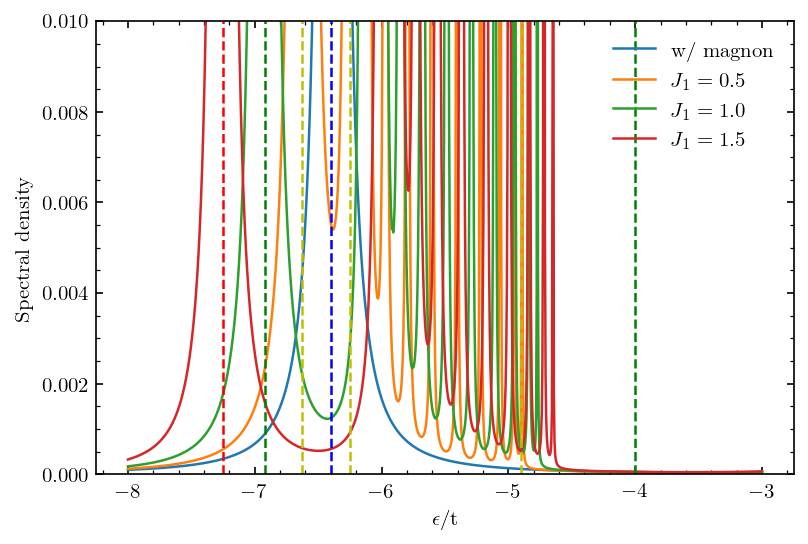

In [10]:
plt.plot(omegas, A_J0_no, label="w/ magnon")
plt.plot(omegas, A_no_05, label="$J_1=0.5$")
plt.plot(omegas, A_no_10, label="$J_1=1.0$")
plt.plot(omegas, A_no_15, label="$J_1=1.5$")

#plt.axvline(1,color='r', linestyle='--')
#plt.axvline(9,color='r', linestyle='--')

plt.axvline(-4,color='g', linestyle='--')
#plt.axvline(-6.15,color='g', linestyle='--')
plt.axvline(-6.25+1.35,color='y', linestyle='--')
plt.axvline(-6.25,color='y', linestyle='--')
plt.axvline(-6.4,color='b', linestyle='--')
plt.axvline(-6.63,color='y', linestyle='--')
plt.axvline(-6.92,color='g', linestyle='--')
plt.axvline(-7.25,color='r', linestyle='--')

plt.legend()
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
#plt.title("tc= 1.0, tv=1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-5")
plt.ylim(0,0.01)

In [11]:
solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.05, J1=0.5, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=20
)
omegas = np.linspace(-7,-4,1000)
A_J0_no = np.array([solver.spectral(0.0, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.05, J1=0.5, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=20
)
A_no_05 = np.array([solver.spectral(0.0, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.1, J1=0.5, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=20
)
A_no_05_M20 = np.array([solver.spectral(0.0, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.11, J1=0.5, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=50
)
A_no_05_M50 = np.array([solver.spectral(0.0, w, eta = 0.001, R=0, m=None,
                                 source='no', Rsrc=0)
                 for w in omegas])

(-7.0, -4.0)

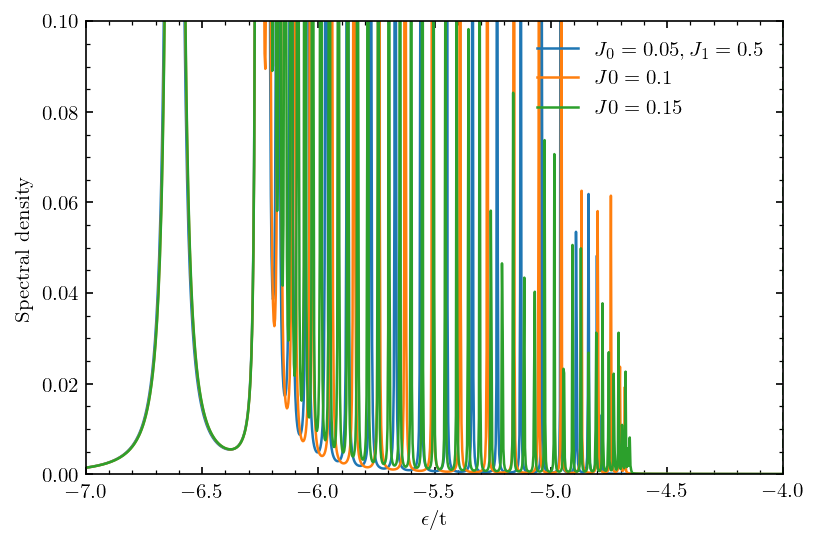

In [12]:
#plt.plot(omegas, A_J0_no, label="w/ magnon")
plt.plot(omegas, A_no_05, label="$J_0=0.05, J_1 = 0.5$")
plt.plot(omegas, A_no_05_M20, label="$J0=0.1$")
plt.plot(omegas, A_no_05_M50, label="$J0=0.15$")
#plt.plot(omegas, A_no_10, label="$J_1=1.0$")
#plt.plot(omegas, A_no_15, label="$J_1=1.5$")

#plt.axvline(1,color='r', linestyle='--')
#plt.axvline(9,color='r', linestyle='--')

plt.axvline(-4,color='g', linestyle='--')
#plt.axvline(-6.4,color='k', linestyle='--')
#plt.axvline(-6.65,color='k', linestyle='--')
#plt.axvline(-6.9,color='k', linestyle='--')
#plt.axvline(-7.15,color='k', linestyle='--')

plt.legend()
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
#plt.title("tc= 1.0, tv=1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-5")
plt.ylim(0,0.1)
plt.xlim(-7,-4)

(0.0, 0.01)

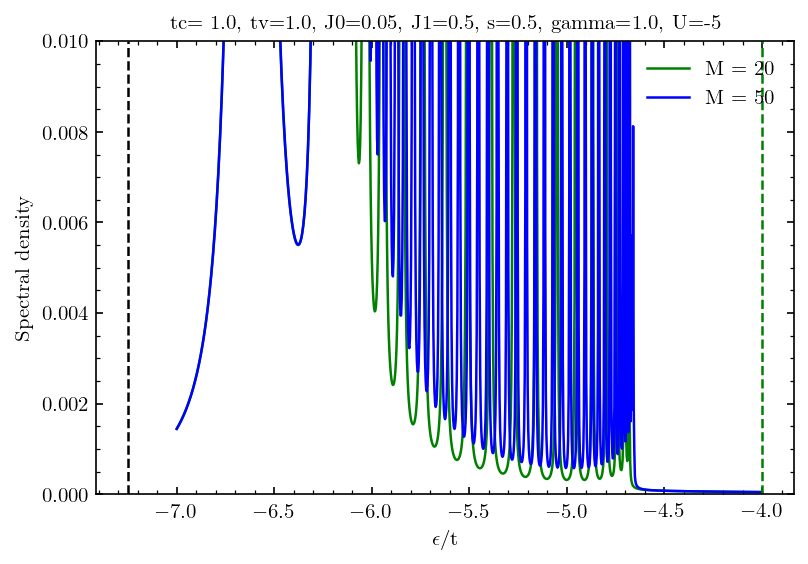

In [13]:
#plt.plot(omegas, A_no_05, "r", label="w/ magnon")
plt.plot(omegas, A_no_05_M20, "g", label="M = 20")
plt.plot(omegas, A_no_05_M50, "b", label="M = 50")

#plt.axvline(1,color='r', linestyle='--')
#plt.axvline(9,color='r', linestyle='--')

plt.axvline(-4,color='g', linestyle='--')
plt.axvline(-7.25,color='k', linestyle='--')

plt.legend()
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
plt.title("tc= 1.0, tv=1.0, J0=0.05, J1=0.5, s=0.5, gamma=1.0, U=-5")
plt.ylim(0,0.01)

(0.0, 0.01)

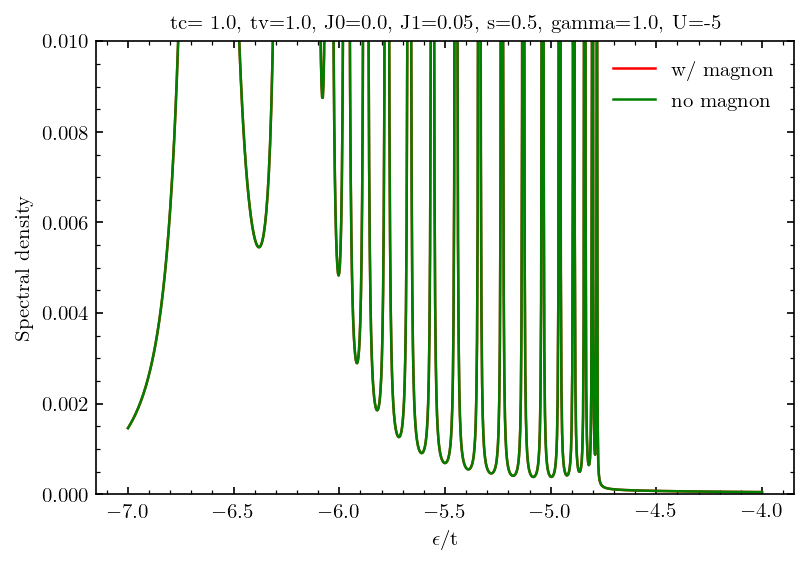

In [14]:
plt.plot(omegas, A_no_05, "r", label="w/ magnon")
plt.plot(omegas, A_J0_no, "g", label="no magnon")

#plt.axvline(1,color='r', linestyle='--')
#plt.axvline(9,color='r', linestyle='--')

#plt.axvline(-4,color='g', linestyle='--')
#plt.axvline(-6.93,color='k', linestyle='--')

plt.legend()
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
plt.title("tc= 1.0, tv=1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-5")
plt.ylim(0,0.01)

Text(0.5, 1.0, 'tc=1.0, tv= 1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-4')

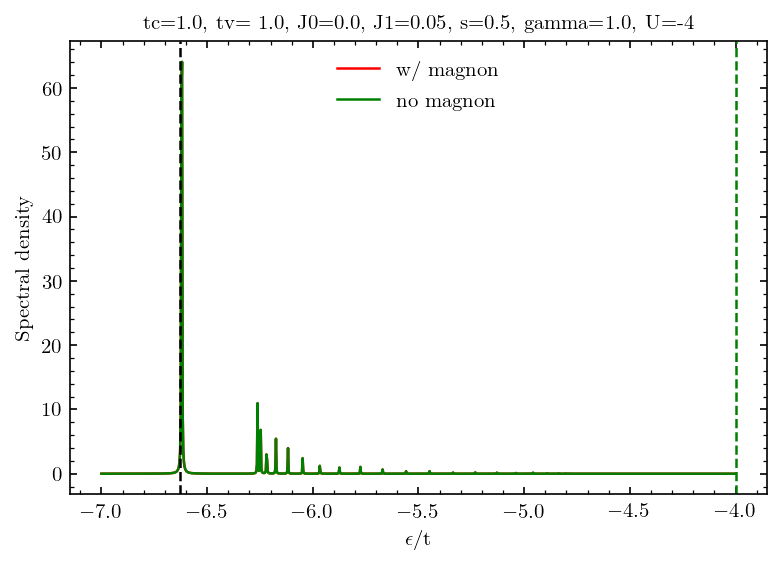

In [15]:
plt.plot(omegas, A_no_05, "r", label="w/ magnon")
plt.plot(omegas, A_J0_no, "g", label="no magnon")

#plt.axvline(1,color='r', linestyle='--')
#plt.axvline(9,color='r', linestyle='--')

plt.axvline(-4,color='g', linestyle='--')
plt.axvline(-6.63,color='k', linestyle='--')

plt.legend()
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
plt.title("tc=1.0, tv= 1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-4")
#plt.ylim(0,0.1)

In [20]:
import os
import numpy as np
from concurrent.futures import ProcessPoolExecutor

params = dict(
    t_c=1.0, t_v=1.0, Delta=0, J0=0.2, J1=0.2, s=0.5, gamma=1.0, U=-1.0,
    Rmax=20, M=5
)

k_values = np.linspace(0, 2*np.pi, 200)
omega_values = np.linspace(-7,0, 400)
eta = 0.05

def compute_column(args):
    k, omega_values, eta, params = args
    solver = ExcitonMagnonSolver(**params)  # build inside worker
    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(k, w, eta=eta, R=0, m=None, source='no', Rsrc=0, msrc=0)
    return col

tasks = [(k, omega_values, eta, params) for k in k_values]

cols = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, col in enumerate(ex.map(compute_column, tasks), 1):
        cols.append(col)
        if i % 10 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} k-columns")

spectral_2d = np.stack(cols, axis=1)  # (Nw, Nk)


Finished 10/200 k-columns
Finished 20/200 k-columns
Finished 30/200 k-columns
Finished 40/200 k-columns
Finished 50/200 k-columns
Finished 60/200 k-columns
Finished 70/200 k-columns
Finished 80/200 k-columns
Finished 90/200 k-columns
Finished 100/200 k-columns
Finished 110/200 k-columns
Finished 120/200 k-columns
Finished 130/200 k-columns
Finished 140/200 k-columns
Finished 150/200 k-columns
Finished 160/200 k-columns
Finished 170/200 k-columns
Finished 180/200 k-columns
Finished 190/200 k-columns
Finished 200/200 k-columns


Plot saved to outputs/spectral_function_2d.png


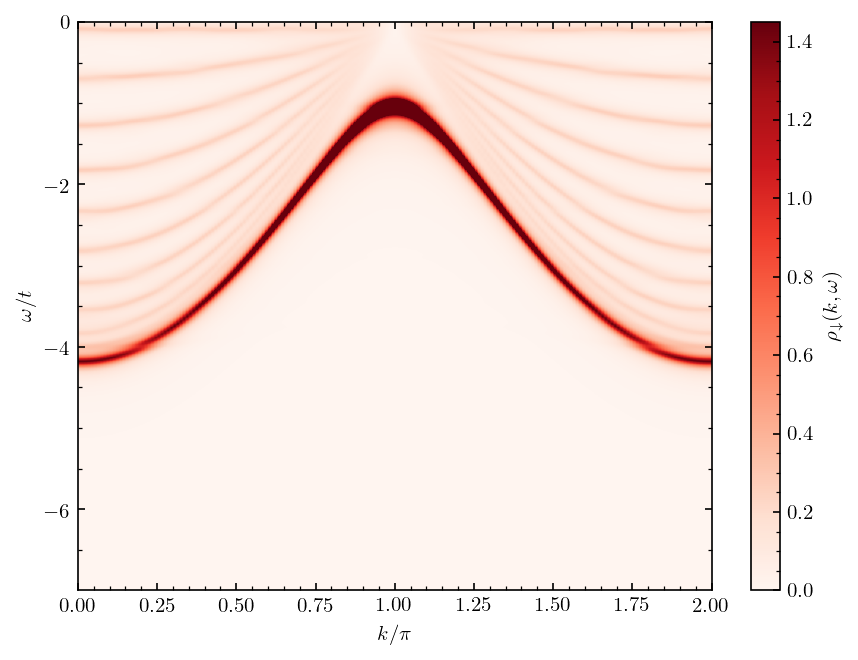

In [21]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 2, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )
t_c=t_v =1
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, +4*t_c*np.cos(k_values))
#plt.plot(k_values/np.pi, -4*t_c*np.cos(k_values))
plt.ylim(-7,0)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')

#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

In [18]:
import os
import numpy as np
from concurrent.futures import ProcessPoolExecutor
s = 0.5
J1 = 2       # <-- works for any J1 now
t = 1.0
J0 = 1.2
gamma = 1.0
t_v = 1.0
U = -0.5
params = dict(
    t_c=t, t_v=t_v, Delta=0, J0=J0, J1=J1, s=s, gamma=gamma, U=U,
    Rmax=12, M=1
)

k_values = np.linspace(0, 2*np.pi, 200)
omega_values = np.linspace(-7,0, 400)
eta = 0.05

def compute_column(args):
    k, omega_values, eta, params = args
    solver = ExcitonMagnonSolver(**params)  # build inside worker
    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(k, w, eta=eta, R=0,m=None, source='no', Rsrc=0, msrc=0)
    return col

tasks = [(k, omega_values, eta, params) for k in k_values]

cols = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, col in enumerate(ex.map(compute_column, tasks), 1):
        cols.append(col)
        if i % 10 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} k-columns")

spectral_2d = np.stack(cols, axis=1)  # (Nw, Nk)


Finished 10/200 k-columns
Finished 20/200 k-columns
Finished 30/200 k-columns
Finished 40/200 k-columns
Finished 50/200 k-columns
Finished 60/200 k-columns
Finished 70/200 k-columns
Finished 80/200 k-columns
Finished 90/200 k-columns
Finished 100/200 k-columns
Finished 110/200 k-columns
Finished 120/200 k-columns
Finished 130/200 k-columns
Finished 140/200 k-columns
Finished 150/200 k-columns
Finished 160/200 k-columns
Finished 170/200 k-columns
Finished 180/200 k-columns
Finished 190/200 k-columns
Finished 200/200 k-columns


Plot saved to outputs/spectral_function_2d.png


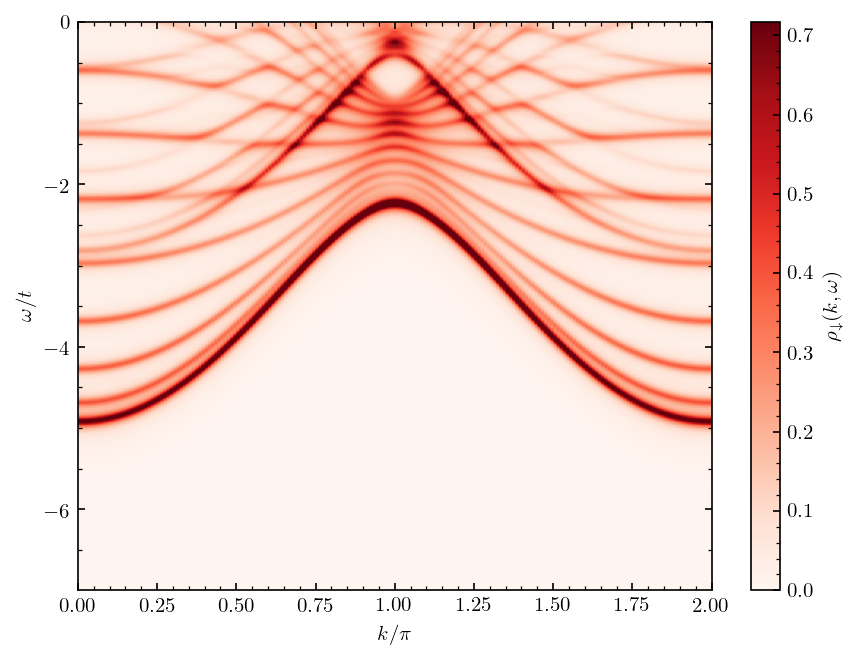

In [19]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 2, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )
t_c=t_v =1
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, +4*t_c*np.cos(k_values))
#plt.plot(k_values/np.pi, -4*t_c*np.cos(k_values))
#plt.ylim(-26,-22)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')

#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

# Finding the spin-polaron-hole continuum.

In [113]:
import os
import numpy as np
from concurrent.futures import ProcessPoolExecutor


s = 0.5
J1 = 0.7# <-- works for any J1 now
t = 1.0
J0 = 0.1
gamma = 1.0
t_v = 1.0
U = -0.4

params = dict(
    t_c=t, t_v=t_v, Delta=0, J0=J0, J1=J1, s=s, gamma=gamma, U=U,
    Rmax=10, M=5
)

k_values = np.linspace(0, 2*np.pi, 200)
omega_values = np.linspace(-7,0, 400)
eta = 0.05

def compute_column(args):
    k, omega_values, eta, params = args
    solver = ExcitonMagnonSolver(**params)  # build inside worker
    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(k, w, eta=eta, R=0, m=None, source='no', Rsrc=0, msrc=0)
    return col

tasks = [(k, omega_values, eta, params) for k in k_values]

cols = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, col in enumerate(ex.map(compute_column, tasks), 1):
        cols.append(col)
        if i % 10 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} k-columns")

spectral_2d = np.stack(cols, axis=1)  # (Nw, Nk)


Finished 10/200 k-columns
Finished 20/200 k-columns
Finished 30/200 k-columns
Finished 40/200 k-columns
Finished 50/200 k-columns
Finished 60/200 k-columns
Finished 70/200 k-columns
Finished 80/200 k-columns
Finished 90/200 k-columns
Finished 100/200 k-columns
Finished 110/200 k-columns
Finished 120/200 k-columns
Finished 130/200 k-columns
Finished 140/200 k-columns
Finished 150/200 k-columns
Finished 160/200 k-columns
Finished 170/200 k-columns
Finished 180/200 k-columns
Finished 190/200 k-columns
Finished 200/200 k-columns


Extracting spin polaron band for J1=0.7...
  Found poles at 500/500 k-points
  Min binding energy: 0.038637
  Max binding energy: 0.459961
Saved plot.
Saved data.


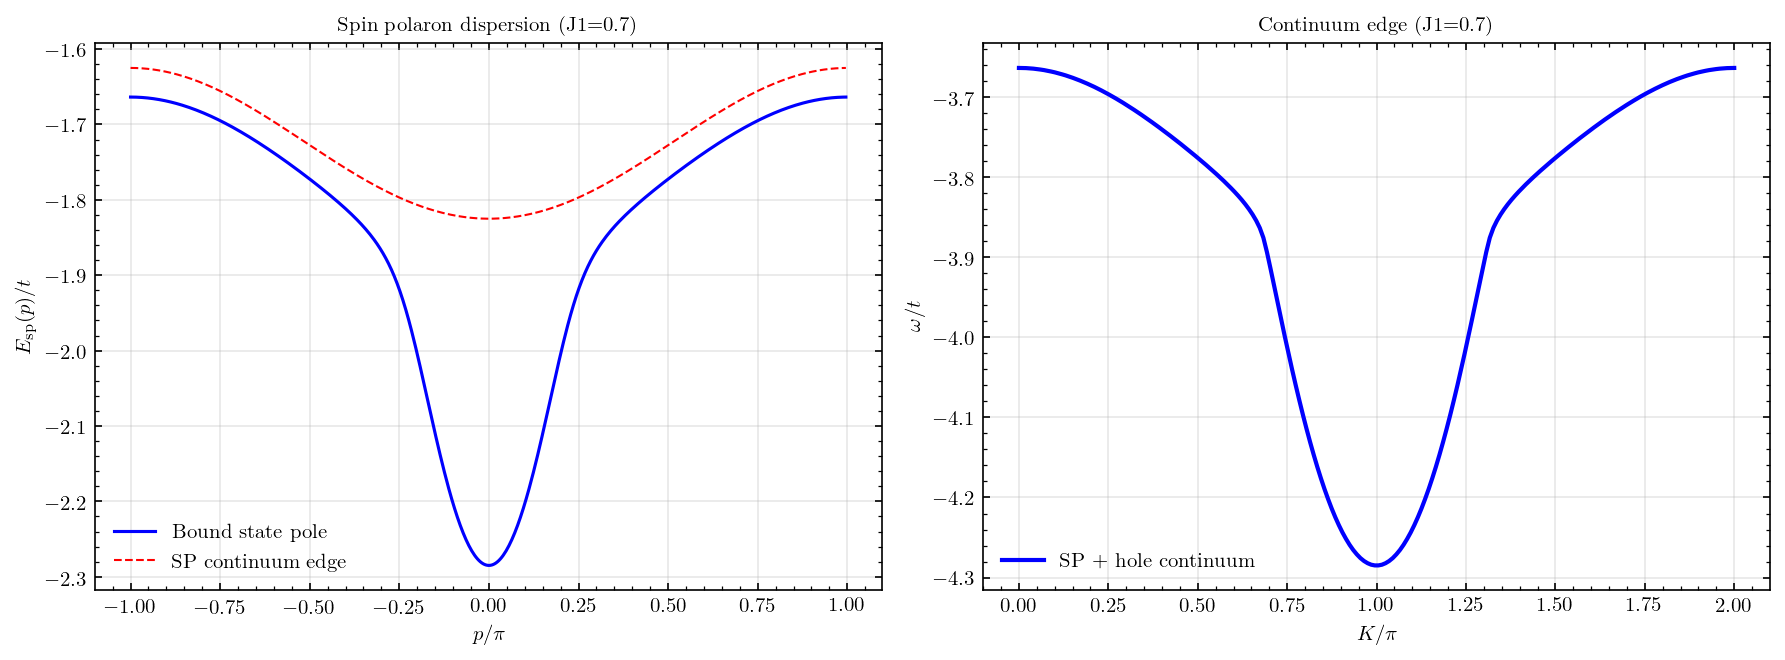

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_1, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_1 = float(J_1)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * (self.s - 1.0)
        g2 = (self.gamma * self.J_1)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) + 0.5 * self.J_1 * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K):
        """
        Evaluate D(omega, K) on the real axis, ASSUMING omega is below the
        spin-polaron continuum so disc > 0 and D is purely real.
        Returns a real float. Use this for brentq.
        """
        omega = float(omega)
        K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        # Below continuum: disc is real and positive
        disc_real = disc.real
        if disc_real < 0:
            disc_real = 0.0  # at the edge
        sqrt_disc = np.sqrt(disc_real)
        # rho candidates (A_minus is complex but for real omega below continuum,
        # A+A- is real, so alpha^2 - 4A+A- is real, and rho is real)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2
        beta = omega - 2.0 * self.J_0 * self.s + 0.5 * self.J_1 * (self.s - 1.0)
        g2 = (self.gamma * self.J_1)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        result = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_1 * self.s - Sigma
        return result.real

    def sp_continuum_edge(self, K):
        """
        Lower edge of the spin-polaron continuum at momentum K.
        This is where disc = alpha^2 - 4 A+ A- = 0.
        The continuum is the electron-magnon scattering states:
           E(K,q) = -2t cos(K-q) + 2 J0 s (1 - cos q) + J1 s / 2
        Minimized over magnon momentum q.
        """
        K = float(K)
        q_grid = np.linspace(-np.pi, np.pi, 5000)
        E_vals = (-2.0 * self.t * np.cos(K - q_grid)
                  + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q_grid))
                  + 0.5 * self.J_1 * self.s)
        return np.min(E_vals)

    def G_minus(self, z, K):
        return 1.0 / self.denominator(z, K)

    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j * eta
        return -np.imag(self.G_minus(z, K)) / np.pi


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    """
    Exact pole extraction.
    1. For each p, compute the spin-polaron continuum edge E_cont(p).
    2. Search for the pole of D(omega, p) = 0 in [wmin, E_cont(p) - padding].
    3. Use a coarse scan + brentq refinement.
    """
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)

    # Step 1: continuum edges (vectorized over q, looped over p)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    # Step 2: for each p, find the pole below E_cont
    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding

        if w_hi <= w_lo:
            continue

        # Coarse scan
        n_scan = 2000
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        # Find sign changes
        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            # Adaptive refinement near the continuum edge
            # Use geometrically spaced points to resolve arbitrarily small binding
            found_fine = False
            for depth in range(8):  # each level 10x finer
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break
                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([pol.denominator_real_below_continuum(w, p)
                                        for w in w_scan_fine])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]
                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i+1], xtol=1e-14)
                            roots.append(root)
                        except:
                            pass
                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break
            if not found_fine:
                continue

        # Refine all brackets, take the lowest
        roots = []
        for i in sign_changes:
            try:
                root = brentq(lambda w: pol.denominator_real_below_continuum(w, p),
                              w_scan[i], w_scan[i+1], xtol=1e-14)
                roots.append(root)
            except:
                pass
        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def spin_polaron_hole_continuum(K_ex_grid, p_grid, E_sp, t_v):
    """
    Exciton-solver convention:
        p_sp + k_h = 2 K_ex
    Hole dispersion:
        E_h(k_h) = -2 t_v cos(k_h)
    So:
        E_cont(K_ex) = min_p [ E_sp(p) - 2 t_v cos(2 K_ex - p) ]
    """
    K_ex_grid = np.asarray(K_ex_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    # Mask out NaN values
    valid = ~np.isnan(E_sp)
    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    E_mat = E_valid[None, :] - 2.0 * t_v * np.cos(K_ex_grid[:, None] - p_valid[None, :])
    idx = np.argmin(E_mat, axis=1)
    E_cont = E_mat[np.arange(K_ex_grid.size), idx]
    p_star = p_valid[idx]
    k_h_star = wrap_to_bz(K_ex_grid - p_star)
    return E_cont, p_star, k_h_star


# =====================================================
# Parameters — change J1 here
# =====================================================

pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_1=J1, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)
print(f"Extracting spin polaron band for J1={J1}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0*t)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex, p_grid=p_grid, E_sp=E_sp, t_v=t_v
)

# 3) Plot spin-polaron band + continuum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(p_grid/np.pi, E_sp, 'b-', lw=1.5, label='Bound state pole')
ax1.plot(p_grid/np.pi, E_sp_cont, 'r--', lw=1, label='SP continuum edge')
ax1.set_xlabel(r'$p/\pi$')
ax1.set_ylabel(r'$E_{\rm sp}(p)/t$')
ax1.set_title(f'Spin polaron dispersion (J1={J1})')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_ex/np.pi, E_cont, 'b-', lw=2, label='SP + hole continuum')
ax2.set_xlabel(r'$K/\pi$')
ax2.set_ylabel(r'$\omega/t$')
ax2.set_title(f'Continuum edge (J1={J1})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sp_continuum_J1_{:.1f}.png'.format(J1), dpi=200, bbox_inches='tight')
print(f"Saved plot.")

# Save data
np.savez('sp_continuum_data_J1_{:.1f}.npz'.format(J1),
         p_grid=p_grid, E_sp=E_sp, E_sp_cont=E_sp_cont,
         K_ex=K_ex, E_cont=E_cont, p_star=p_star, k_h_star=k_h_star)
print("Saved data.")
plt.show()

In [115]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def exciton_bound_energy(k_red, t_c, t_v, U, J1=0.0, s=0.5, include_solver_shift=True):
    """
    Exact exciton bound-state dispersion in the reduced momentum variable k_red,
    where the formula depends on cos(2 k_red).

    k_red can be scalar or array.
    """
    A = t_c**2 + t_v**2 + 2.0*t_c*t_v*np.cos(k_red)
    E = -np.sqrt(U**2 + 4.0*A)   # lower / bound branch
    if include_solver_shift:
        E = E - 0.5*J1*s
    return E

def magnon_dispersion(q, J0, s, J1):
    """
    Exact 1D FM magnon dispersion in the same energy convention as your solver.
    """
    return 2.0*J0*s*(1.0 - np.cos(q)) + J1*s

def exciton_magnon_continuum(K_grid, t_c, t_v, U, J0, s, J1=0.0,
                             nq=2001, include_solver_shift=True):
    """
    Exciton + magnon continuum in the exciton-magnon solver convention.

    K_grid: solver momentum variable K in [0, pi]
    q: physical magnon momentum in [-pi, pi)
    Exciton reduced momentum is k_X = K - q/2, so cos(2 k_X) = cos(2K - q).

    Returns:
      E_low(K), E_high(K), q_star_low(K), q_star_high(K), E_all(K,q)
    """
    K_grid = np.asarray(K_grid, dtype=float)
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)

    # Broadcast over K and q
    K2 = K_grid[:, None]
    Q  = q_grid[None, :]

    # Exciton reduced momentum in your exact formula
    kX = K2 - Q

    EX = exciton_bound_energy(
        kX, t_c=t_c, t_v=t_v, U=U, J1=J1, s=s,
        include_solver_shift=include_solver_shift
    )
    WM = magnon_dispersion(Q, J0=J0, s=s, J1=J1)

    E_all = EX + WM

    idx_low  = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    E_low  = E_all[np.arange(len(K_grid)), idx_low]
    E_high = E_all[np.arange(len(K_grid)), idx_high]

    q_star_low  = q_grid[idx_low]
    q_star_high = q_grid[idx_high]

    return E_low, E_high, q_star_low, q_star_high, q_grid, E_all

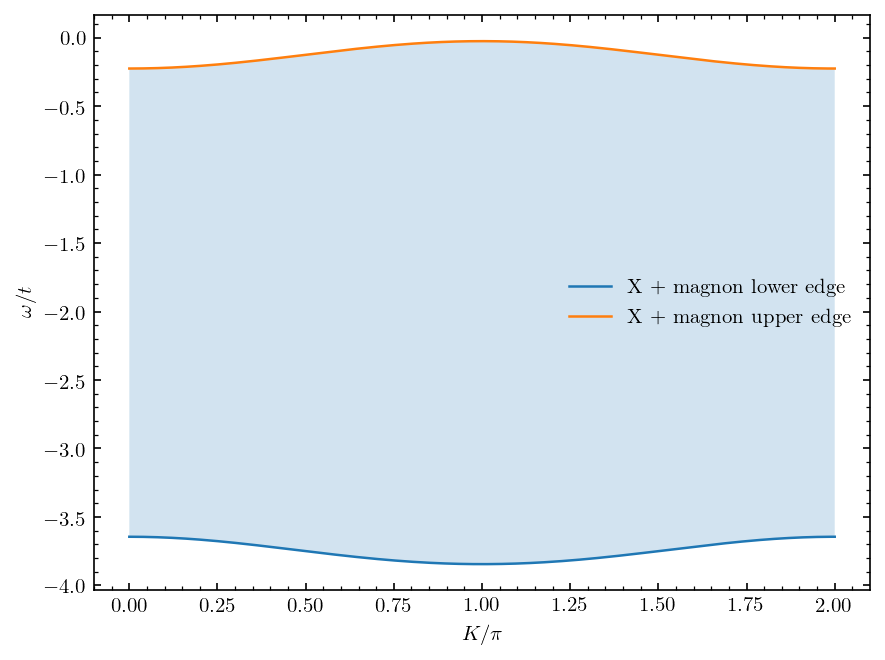

In [116]:
# Parameters


K_grid = k_values

E_low, E_high, q_low, q_high, q_grid, E_all = exciton_magnon_continuum(
    K_grid,
    t_c=t_c,
    t_v=t_v,
    U=U,
    J0=J0,
    s=s,
    J1=J1,
    nq=2001,
    include_solver_shift=True,   # set False if you want the bare analytic zero
)

# Plot edges
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(K_grid/np.pi, E_low,  label='X + magnon lower edge')
ax.plot(K_grid/np.pi, E_high, label='X + magnon upper edge')
ax.fill_between(K_grid/np.pi, E_low, E_high, alpha=0.2)
ax.set_xlabel(r'$K/\pi$')
ax.set_ylabel(r'$\omega/t$')
ax.legend()
plt.tight_layout()
plt.show()

In [117]:
"""x = np.linspace(0, np.pi, 200)
y = np.linspace(-np.pi, np.pi, 200)

# Create the coordinate grid
X, Y = np.meshgrid(x, y)

# Evaluate the function (e.g., f(x,y) = x^2 + y^2)
matrix_f = -J1 - 0.95*t*np.cos(X+Y) - 2*t*np.cos(X-Y)
#matrix_f_abs = -2 - 0.95*np.cos(Y) + 2*np.cos(X - Y)#-J1 + 0.95*t*np.cos(X) + 2*t*np.cos(X-Y)

# Find the minimum value for each y
min_values = np.min(matrix_f, axis=0)
#min_values_abs = np.min(matrix_f_abs, axis=0)

# Find the specific x-index that produced that minimum
min_indices = np.argmin(matrix_f, axis=1)

# Get the actual x values that minimize the function for each y
optimal_x_values = x[min_indices]
fig, ax = plt.subplots(figsize=(6, 4.5))
plt.plot(k_values/np.pi, min_values)
#plt.plot(k_values/np.pi, min_values_abs)
plt.show()"""

'x = np.linspace(0, np.pi, 200)\ny = np.linspace(-np.pi, np.pi, 200)\n\n# Create the coordinate grid\nX, Y = np.meshgrid(x, y)\n\n# Evaluate the function (e.g., f(x,y) = x^2 + y^2)\nmatrix_f = -J1 - 0.95*t*np.cos(X+Y) - 2*t*np.cos(X-Y)\n#matrix_f_abs = -2 - 0.95*np.cos(Y) + 2*np.cos(X - Y)#-J1 + 0.95*t*np.cos(X) + 2*t*np.cos(X-Y)\n\n# Find the minimum value for each y\nmin_values = np.min(matrix_f, axis=0)\n#min_values_abs = np.min(matrix_f_abs, axis=0)\n\n# Find the specific x-index that produced that minimum\nmin_indices = np.argmin(matrix_f, axis=1)\n\n# Get the actual x values that minimize the function for each y\noptimal_x_values = x[min_indices]\nfig, ax = plt.subplots(figsize=(6, 4.5))\nplt.plot(k_values/np.pi, min_values)\n#plt.plot(k_values/np.pi, min_values_abs)\nplt.show()'

In [118]:
pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_1=J1, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 400, endpoint=False)
print(f"Extracting spin polaron band for J1={J1}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0*t)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex, p_grid=p_grid, E_sp=E_sp, t_v=t_v
)

Extracting spin polaron band for J1=0.7...


/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: invalid value encountered in cdouble_scalars


  Found poles at 400/400 k-points
  Min binding energy: 0.038637
  Max binding energy: 0.459961


Plot saved to outputs/spectral_function_2d.png


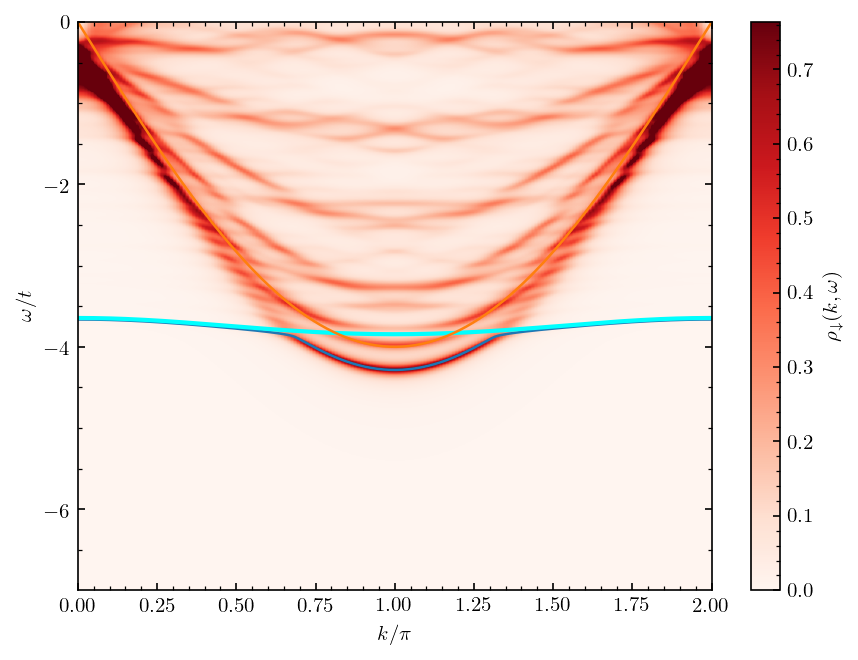

In [120]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 2, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )
t_c=t_v =1
ax.plot(k_values/np.pi, E_cont, label="spin-polaron+hole")
ax.plot(K_grid/np.pi, E_low, color='cyan', lw=2)
#plt.plot(k_values/np.pi, min_values_abs)
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, -4*np.abs(t_c*np.cos(k_values)))
plt.plot(k_values/np.pi, -4*t_c*np.abs(np.sin(k_values/2)))
#plt.ylim(-4.4,-4.2)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')

#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

In [ ]:
import os
import numpy as np
from concurrent.futures import ProcessPoolExecutor


s = 0.5
J1 = 0.7# <-- works for any J1 now
t = 1.0
J0 = 0.1
gamma = 1.0
t_v = 0.0
U = -0.4

params = dict(
    t_c=t, t_v=t_v, Delta=0, J0=J0, J1=J1, s=s, gamma=gamma, U=U,
    Rmax=10, M=5
)

k_values = np.linspace(0, 2*np.pi, 200)
omega_values = np.linspace(-7,0, 400)
eta = 0.05

def compute_column(args):
    k, omega_values, eta, params = args
    solver = ExcitonMagnonSolver(**params)  # build inside worker
    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(k, w, eta=eta, R=0, m=None, source='no', Rsrc=0, msrc=0)
    return col

tasks = [(k, omega_values, eta, params) for k in k_values]

cols = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, col in enumerate(ex.map(compute_column, tasks), 1):
        cols.append(col)
        if i % 10 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} k-columns")

spectral_2d = np.stack(cols, axis=1)  # (Nw, Nk)


In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 2, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )
t_c=t_v =1
#ax.plot(k_values/np.pi, E_cont, label="spin-polaron+hole")
##ax.plot(K_grid/np.pi, E_low, color='cyan', lw=2)
#plt.plot(k_values/np.pi, min_values_abs)
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, -4*np.abs(t_c*np.cos(k_values)))
plt.plot(k_values/np.pi, -4*t_c*np.abs(np.sin(k_values/2)))
#plt.ylim(-4.4,-4.2)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')

#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

# When does the two continuum cross?

Finished 5/60 J1 runs
Finished 10/60 J1 runs
Finished 15/60 J1 runs
Finished 20/60 J1 runs
Finished 25/60 J1 runs
Finished 30/60 J1 runs
Finished 35/60 J1 runs
Finished 40/60 J1 runs
Finished 45/60 J1 runs
Finished 50/60 J1 runs
Finished 55/60 J1 runs
Finished 60/60 J1 runs


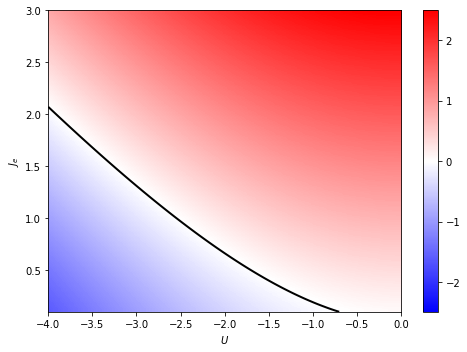

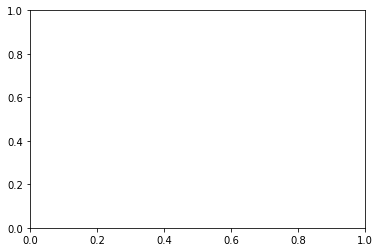

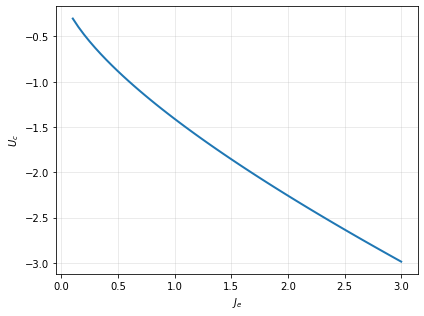

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import get_context


# ---------------------------------------------------------
# Your existing classes / functions
# ---------------------------------------------------------
class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_1, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_1 = float(J_1)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s + 0.5 * self.J_1 * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * (self.s - 1.0)
        g2 = (self.gamma * self.J_1)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) - 0.5 * self.J_1 * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K, tol=1e-14, blowup=1e300):
        """
        Real-axis denominator below the continuum, with explicit handling of
        self-energy poles to avoid warnings / NaNs during scans.
        """
        omega = float(omega)
        K = float(K)

        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0

        alpha = omega - 2.0 * self.J_0 * self.s + 0.5 * self.J_1 * self.s
        disc = alpha**2 - 4.0 * (A_plus * A_minus)

        # below continuum this should be real and >= 0 up to roundoff
        disc_real = disc.real
        if disc_real < 0 and disc_real > -1e-12:
            disc_real = 0.0
        elif disc_real < 0:
            # outside intended domain
            return np.nan

        sqrt_disc = np.sqrt(disc_real)

        # choose decaying branch
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2

        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * (self.s - 1.0)
        g2 = (self.gamma * self.J_1)**2 * self.s / 2.0

        denom_sigma = beta + 2.0 * A_minus * rho

        # below continuum this should be real up to roundoff
        denom_sigma_real = denom_sigma.real

        bare = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_1 * self.s

        # handle self-energy pole explicitly
        if abs(denom_sigma_real) < tol:
            return -np.copysign(blowup, denom_sigma_real if denom_sigma_real != 0.0 else 1.0)

        return bare - g2 / denom_sigma_real

    def sp_continuum_edge(self, K):
        K = float(K)
        q_grid = np.linspace(-np.pi, np.pi, 5000)
        E_vals = (-2.0 * self.t * np.cos(K - q_grid)
                  + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q_grid))
                  + 0.5 * self.J_1 * self.s)
        return np.min(E_vals)


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding
        if w_hi <= w_lo:
            continue

        n_scan = 2000
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            found_fine = False
            for depth in range(8):
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break
                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([pol.denominator_real_below_continuum(w, p)
                                        for w in w_scan_fine])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]
                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i + 1], xtol=1e-14
                            )
                            roots.append(root)
                        except Exception:
                            pass
                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break
            if not found_fine:
                continue

        roots = []
        for i in sign_changes:
            try:
                root = brentq(
                    lambda w: pol.denominator_real_below_continuum(w, p),
                    w_scan[i], w_scan[i + 1], xtol=1e-14
                )
                roots.append(root)
            except Exception:
                pass
        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def exciton_magnon_edge_K0(U, J1, t_c, t_v, s):
    return +0.5 * J1 * s - np.sqrt(U**2 + 4.0 * (t_c + t_v)**2)


def spin_polaron_hole_edge_K0(pol, p_grid, t_v, wmin=-8.0):
    E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=wmin)
    valid = np.isfinite(E_sp)
    if not np.any(valid):
        return np.nan, np.nan

    vals = E_sp[valid] - 2.0 * t_v * np.cos(p_grid[valid])
    idx = np.argmin(vals)
    return vals[idx], p_grid[valid][idx]


# ---------------------------------------------------------
# Parallel worker
# ---------------------------------------------------------
def _compute_one_J1(job):
    """
    Top-level function so it is picklable by ProcessPoolExecutor.
    """
    J1, t, J0, s, gamma, t_v, p_points, wmin = job

    p_grid = np.linspace(-np.pi, np.pi, p_points, endpoint=False)
    pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_1=J1, s=s, gamma=gamma)
    E_edge, p_star = spin_polaron_hole_edge_K0(pol, p_grid=p_grid, t_v=t_v, wmin=wmin)

    return J1, E_edge, p_star


import os
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# ---------------------------------------------------
# Worker: one independent J1 job
# ---------------------------------------------------
def compute_one_J1(args):
    J1, p_grid, t, J0, s, gamma, t_v, wmin = args

    pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_1=J1, s=s, gamma=gamma)

    # exact standalone spin-polaron band
    E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=wmin)

    valid = ~np.isnan(E_sp)
    if not np.any(valid):
        return np.nan, np.nan, E_sp, E_sp_cont

    # K_ex = 0  =>  p_sp + k_h = 0  =>  k_h = -p_sp
    # E_h(-p) = -2 t_v cos(p)
    vals = E_sp[valid] - 2.0 * t_v * np.cos(p_grid[valid])
    idx = np.argmin(vals)

    E_edge = vals[idx]
    p_star = p_grid[valid][idx]

    return E_edge, p_star, E_sp, E_sp_cont


# ---------------------------------------------------
# Parameters
# ---------------------------------------------------
t_c = 1.0
t_v = 1.0
t   = 1.0
J0  = 0.1
s   = 0.5
gamma = 1.0

# scan ranges
U_grid  = np.linspace(-4.0, 0.0, 301)
J1_grid = np.linspace(0.1, 3.0, 60)

# momentum grid for standalone spin polaron
p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)

# lower search bound for pole finder
wmin = -8.0 * t

tasks = [(J1, p_grid, t, J0, s, gamma, t_v, wmin) for J1 in J1_grid]

E_sph = np.full(len(J1_grid), np.nan)
p_star = np.full(len(J1_grid), np.nan)

# optional: keep these if you want diagnostics later
E_sp_all = []
E_sp_cont_all = []

with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, result in enumerate(ex.map(compute_one_J1, tasks), 1):
        E_edge, pmin, E_sp, E_sp_cont = result
        E_sph[i-1] = E_edge
        p_star[i-1] = pmin
        E_sp_all.append(E_sp)
        E_sp_cont_all.append(E_sp_cont)

        if i % 5 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} J1 runs")
            
# ---------------------------------------------------
# Exciton + magnon lower edge at K=0
# direct-gap assumption => minimum at q=0
# ---------------------------------------------------
E_xm = (
    +0.5 * s * J1_grid[:, None]
    - np.sqrt(U_grid[None, :]**2 + 4.0 * (t_c + t_v)**2)
)

# difference:
# Delta < 0  => exciton+magnon lower
# Delta > 0  => spin-polaron+hole lower
Delta = E_xm - E_sph[:, None]

# exact crossover U_c(J1) from Delta = 0
rhs = (-E_sph - 0.5 * s * J1_grid)**2 - 4.0 * (t_c + t_v)**2
U_cross = np.full_like(J1_grid, np.nan, dtype=float)
mask = np.isfinite(rhs) & (rhs >= 0.0)
U_cross[mask] = -np.sqrt(rhs[mask])
from matplotlib.colors import TwoSlopeNorm

v = np.nanmax(np.abs(Delta))   # symmetric range around 0
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    Delta,
    origin='lower',
    aspect='auto',
    extent=[U_grid[0], U_grid[-1], J1_grid[0], J1_grid[-1]],
    cmap='bwr',   # blue-white-red
    norm=norm
)

ax.contour(
    U_grid,
    J1_grid,
    Delta,
    levels=[0.0],
    colors='k',
    linewidths=2
)

cbar = plt.colorbar(im, ax=ax)
#cbar.set_label(r'$\Delta = E_{X+m}(0) - E_{sp+h}(0)$')

ax.set_xlabel(r'$U$')
ax.set_ylabel(r'$J_e$')
#ax.set_title(r'Crossover at $K=0$')
plt.tight_layout()
plt.show()

ax.contour(
    U_grid,
    J1_grid,
    Delta,
    levels=[0.0],
    colors='k',
    linewidths=2
)

cbar = plt.colorbar(im, ax=ax)
#cbar.set_label(r'$\Delta = E_{X+m}(0) - E_{sp+h}(0)$')



fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(J1_grid, U_cross, lw=2)
ax.set_xlabel(r'$J_e$')
ax.set_ylabel(r'$U_c$')
#ax.set_title(r'Crossover line at $K=0$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in cdou

/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in cdoub

Finished 5/60 J1 runs
Finished 10/60 J1 runs
Finished 15/60 J1 runs
Finished 20/60 J1 runs
Finished 25/60 J1 runs
Finished 30/60 J1 runs
Finished 35/60 J1 runs
Finished 40/60 J1 runs
Finished 45/60 J1 runs
Finished 50/60 J1 runs
Finished 55/60 J1 runs
Finished 60/60 J1 runs


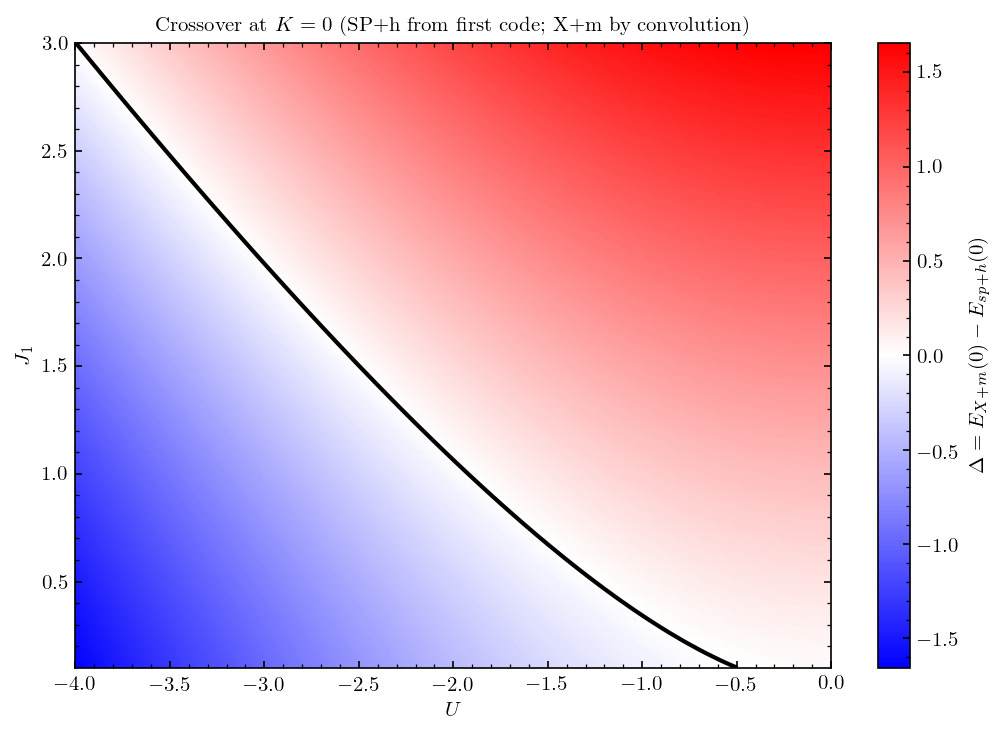

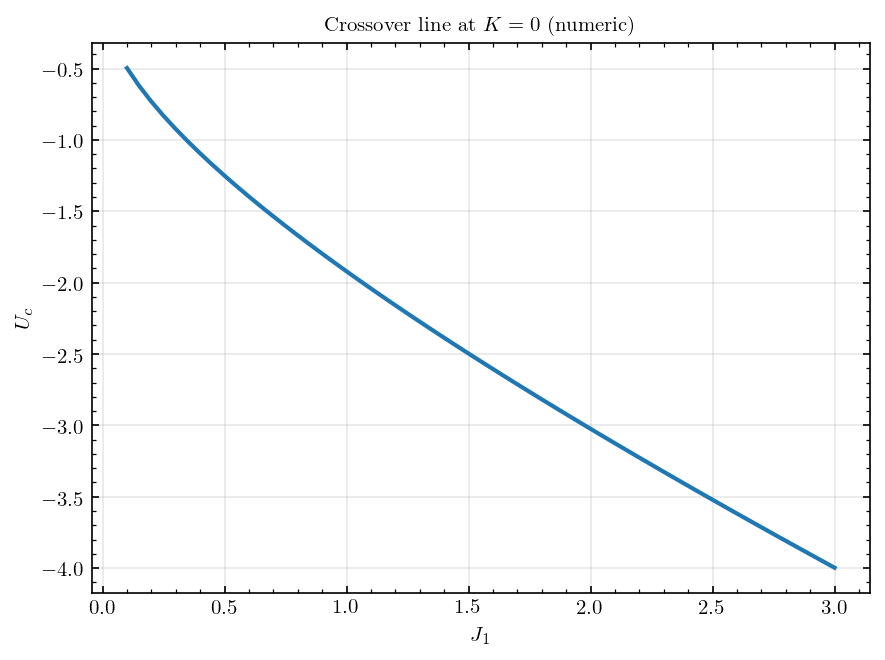

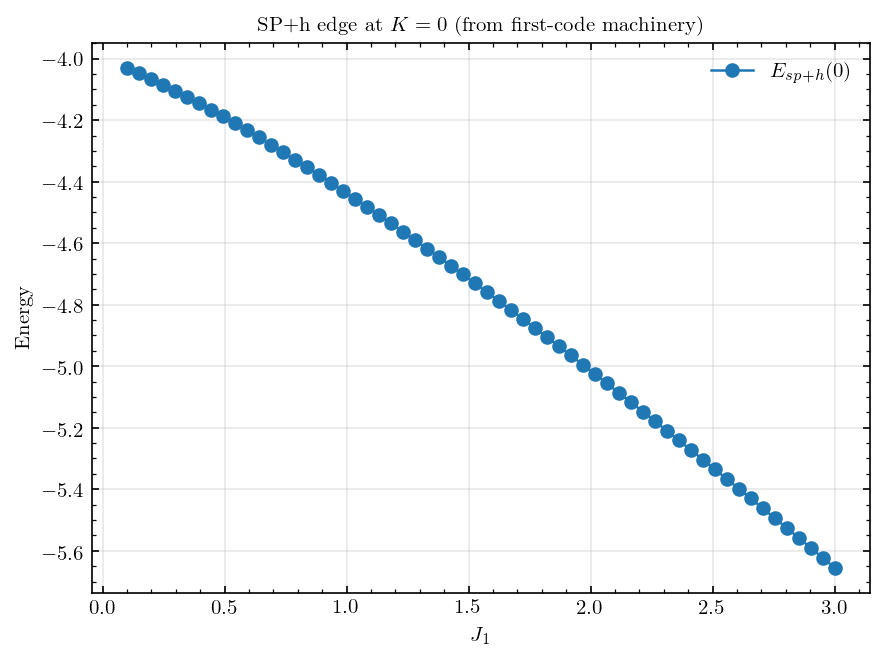

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from concurrent.futures import ProcessPoolExecutor
from matplotlib.colors import TwoSlopeNorm

# =========================================================
# SPIN-POLARON SIDE (VERBATIM FROM YOUR FIRST CODE)
# =========================================================

class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_1, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_1 = float(J_1)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * (self.s - 1.0)
        g2 = (self.gamma * self.J_1)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) + 0.5 * self.J_1 * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K):
        """
        Evaluate D(omega, K) on the real axis, ASSUMING omega is below the
        spin-polaron continuum so disc > 0 and D is purely real.
        Returns a real float. Use this for brentq.
        """
        omega = float(omega)
        K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus

        disc_real = disc.real
        if disc_real < 0:
            disc_real = 0.0  # at the edge / roundoff
        sqrt_disc = np.sqrt(disc_real)

        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2

        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_1 * (self.s - 1.0)
        g2 = (self.gamma * self.J_1)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        result = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_1 * self.s - Sigma
        return result.real

    def sp_continuum_edge(self, K):
        """
        Lower edge of the spin-polaron continuum at momentum K:
            E(K,q) = -2t cos(K-q) + 2 J0 s (1 - cos q) + J1 s / 2
        minimized over magnon momentum q.
        """
        K = float(K)
        q_grid = np.linspace(-np.pi, np.pi, 5000)
        E_vals = (-2.0 * self.t * np.cos(K - q_grid)
                  + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q_grid))
                  + 0.5 * self.J_1 * self.s)
        return np.min(E_vals)

    def G_minus(self, z, K):
        return 1.0 / self.denominator(z, K)

    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j * eta
        return -np.imag(self.G_minus(z, K)) / np.pi


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    """
    Exact pole extraction from the FIRST CODE.
    """
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)

    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding

        if w_hi <= w_lo:
            continue

        # coarse scan
        n_scan = 2000
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            # adaptive refinement near the continuum edge
            found_fine = False
            for depth in range(8):
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break

                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([
                    pol.denominator_real_below_continuum(w, p)
                    for w in w_scan_fine
                ])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]

                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i+1],
                                xtol=1e-14
                            )
                            roots.append(root)
                        except Exception:
                            pass

                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break

            if not found_fine:
                continue

        roots = []
        for i in sign_changes:
            try:
                root = brentq(
                    lambda w: pol.denominator_real_below_continuum(w, p),
                    w_scan[i], w_scan[i+1],
                    xtol=1e-14
                )
                roots.append(root)
            except Exception:
                pass

        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def spin_polaron_hole_continuum(K_ex_grid, p_grid, E_sp, t_v):
    """
    Continuum builder from the FIRST CODE logic, using your K (not 2K) convention:
      E_cont(K) = min_p [ E_sp(p) - 2 t_v cos(K - p) ]
    """
    K_ex_grid = np.asarray(K_ex_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = ~np.isnan(E_sp)
    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    E_mat = E_valid[None, :] - 2.0 * t_v * np.cos(K_ex_grid[:, None] - p_valid[None, :])
    idx = np.argmin(E_mat, axis=1)
    E_cont = E_mat[np.arange(K_ex_grid.size), idx]
    p_star = p_valid[idx]
    k_h_star = wrap_to_bz(K_ex_grid - p_star)
    return E_cont, p_star, k_h_star


# =========================================================
# EXCITON + MAGNON SIDE (MOMENTUM-CONVOLVED LOWER EDGE)
# =========================================================

def exciton_dispersion(k, U, t_c, t_v, extra_shift=0.0):
    """
    Exciton branch with curvature matching your spectrum:
        E_X(k) = -sqrt(U^2 + 4 (t_c + t_v)^2 cos^2(k/2)) + extra_shift
    """
    k = np.asarray(k, dtype=float)
    E = -np.sqrt(U**2 + 4.0 * (t_c + t_v)**2 * np.cos(0.5 * k)**2)
    return E + float(extra_shift)

def magnon_dispersion(q, J0, s):
    """
    Same magnon as in the SP continuum: Ω(q) = 2 J0 s (1 - cos q).
    """
    q = np.asarray(q, dtype=float)
    return 2.0 * J0 * s * (1.0 - np.cos(q))

def exciton_magnon_continuum(K_grid, U, t_c, t_v, J0, s, nq=4096, extra_shift=0.0):
    """
    Build the X+m lower edge via minimization over magnon momentum:
        E_{X+m}(K) = min_q [ E_X(K - q) + Ω(q) ].
    Uses the same K convention and Ω(q) as SP code.
    """
    K_grid = np.asarray(K_grid, dtype=float)
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)
    Omega_q = magnon_dispersion(q_grid, J0, s)

    E_edge = np.empty_like(K_grid, dtype=float)
    q_star = np.empty_like(K_grid, dtype=float)

    for i, K in enumerate(K_grid):
        k_ex = wrap_to_bz(K - q_grid)
        E_vals = exciton_dispersion(k_ex, U, t_c, t_v, extra_shift=extra_shift) + Omega_q
        j = np.argmin(E_vals)
        E_edge[i] = E_vals[j]
        q_star[i] = q_grid[j]

    return E_edge, q_star


# =========================================================
# PARALLEL WORKER (SP+h from FIRST CODE)
# =========================================================

def compute_one_J1_from_first_code(args):
    """
    Use ONLY the first-code machinery to compute the spin-polaron+hole edge at K=0.
    """
    J1, t, J0, s, gamma, t_v, p_points, wmin = args

    p_grid = np.linspace(-np.pi, np.pi, p_points, endpoint=False)
    pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_1=J1, s=s, gamma=gamma)

    # exact standalone spin-polaron band from FIRST CODE
    E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=wmin)

    valid = np.isfinite(E_sp)
    if not np.any(valid):
        return {
            "J1": J1,
            "E_sph_K0": np.nan,
            "p_star_K0": np.nan,
            "k_h_star_K0": np.nan,
            "n_valid": 0,
            "binding_min": np.nan,
            "binding_max": np.nan,
        }

    # Build the SP+h continuum using the SAME function as the first code
    K_ex_grid = np.array([0.0])
    E_cont_K0, p_star_K0, k_h_star_K0 = spin_polaron_hole_continuum(
        K_ex_grid=K_ex_grid,
        p_grid=p_grid,
        E_sp=E_sp,
        t_v=t_v
    )

    # Optional sanity check for K=0:
    vals_direct = E_sp[valid] - 2.0 * t_v * np.cos(p_grid[valid])
    E_direct = np.min(vals_direct)
    if not np.allclose(E_cont_K0[0], E_direct, atol=1e-10, rtol=1e-10):
        print(f"[WARNING] K=0 mismatch at J1={J1:.6f}: "
              f"general={E_cont_K0[0]:.12f}, direct={E_direct:.12f}")

    binding = E_sp_cont - E_sp

    return {
        "J1": J1,
        "E_sph_K0": float(E_cont_K0[0]),
        "p_star_K0": float(p_star_K0[0]),
        "k_h_star_K0": float(k_h_star_K0[0]),
        "n_valid": int(np.sum(valid)),
        "binding_min": float(np.nanmin(binding)),
        "binding_max": float(np.nanmax(binding)),
    }


# =========================================================
# MAIN SCAN
# =========================================================

# scanning grids
U_grid  = np.linspace(-4.0, 0.0, 301)
J1_grid = np.linspace(0.1, 3.0, 60)

# momentum grid for standalone spin polaron
p_points = 500

# lower search bound for pole finder
wmin = -8.0 * t

# exciton-magnon building options
EXCITON_NQ = 4096
USE_EXCITON_SHIFT = False  # set True ONLY if you confirm your spectrum uses that reference

# ------------------------
# parallel jobs for SP+h (K=0)
# ------------------------
tasks = [(J1, t, J0, s, gamma, t_v, p_points, wmin) for J1 in J1_grid]

E_sph_K0 = np.full(len(J1_grid), np.nan)
p_star_K0 = np.full(len(J1_grid), np.nan)
k_h_star_K0 = np.full(len(J1_grid), np.nan)
n_valid_arr = np.full(len(J1_grid), 0, dtype=int)
bind_min_arr = np.full(len(J1_grid), np.nan)
bind_max_arr = np.full(len(J1_grid), np.nan)

with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, result in enumerate(ex.map(compute_one_J1_from_first_code, tasks), 1):
        idx = i - 1
        E_sph_K0[idx]   = result["E_sph_K0"]
        p_star_K0[idx]  = result["p_star_K0"]
        k_h_star_K0[idx] = result["k_h_star_K0"]
        n_valid_arr[idx] = result["n_valid"]
        bind_min_arr[idx] = result["binding_min"]
        bind_max_arr[idx] = result["binding_max"]

        if i % 5 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} J1 runs")

# ------------------------
# exciton + magnon edge at K=0 via momentum convolution
# ------------------------
E_xm_K0 = np.full((len(J1_grid), len(U_grid)), np.nan)
for iJ, J1 in enumerate(J1_grid):
    extra_shift = (-0.5 * s * J1) if USE_EXCITON_SHIFT else 0.0
    for iU, U in enumerate(U_grid):
        E_edge, _ = exciton_magnon_continuum(
            K_grid=np.array([0.0]),
            U=U, t_c=t_c, t_v=t_v, J0=J0, s=s,
            nq=EXCITON_NQ, extra_shift=extra_shift
        )
        E_xm_K0[iJ, iU] = E_edge[0]

# difference:
# Delta < 0  => exciton+magnon lower
# Delta > 0  => spin-polaron+hole lower
Delta = E_xm_K0 - E_sph_K0[:, None]

# Numeric crossover U_c(J1): find sign change in each J1 row
U_cross = np.full_like(J1_grid, np.nan, dtype=float)
for iJ in range(len(J1_grid)):
    row = Delta[iJ, :]
    sgn = np.sign(row)
    # indices where sign changes between consecutive U samples
    idxs = np.where(np.diff(sgn) != 0)[0]
    if idxs.size > 0:
        j = idxs[0]
        u1, u2 = U_grid[j], U_grid[j+1]
        y1, y2 = row[j], row[j+1]
        # linear interpolation of the root
        U_cross[iJ] = u1 - y1 * (u2 - u1) / (y2 - y1)

# ------------------------
# plots
# ------------------------
v = np.nanmax(np.abs(Delta))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    Delta,
    origin='lower',
    aspect='auto',
    extent=[U_grid[0], U_grid[-1], J1_grid[0], J1_grid[-1]],
    cmap='bwr',
    norm=norm
)

# zero contour: E_xm(0) - E_sph(0) = 0
ax.contour(
    U_grid,
    J1_grid,
    Delta,
    levels=[0.0],
    colors='k',
    linewidths=2
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\Delta = E_{X+m}(0) - E_{sp+h}(0)$')

ax.set_xlabel(r'$U$')
ax.set_ylabel(r'$J_1$')
ax.set_title(r'Crossover at $K=0$ (SP+h from first code; X+m by convolution)')
plt.tight_layout()
plt.show()

# numeric U_c curve (from row-wise sign changes)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(J1_grid, U_cross, lw=2)
ax.set_xlabel(r'$J_1$')
ax.set_ylabel(r'$U_c$')
ax.set_title(r'Crossover line at $K=0$ (numeric)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# diagnostic: SP+h edge vs J1 (K=0)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(J1_grid, E_sph_K0, 'o-', label=r'$E_{sp+h}(0)$')
ax.set_xlabel(r'$J_1$')
ax.set_ylabel(r'Energy')
ax.set_title(r'SP+h edge at $K=0$ (from first-code machinery)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# the exciton in weak U and strong U are continuously connected.

All done — building figure.


NameError: name 'min_values' is not defined

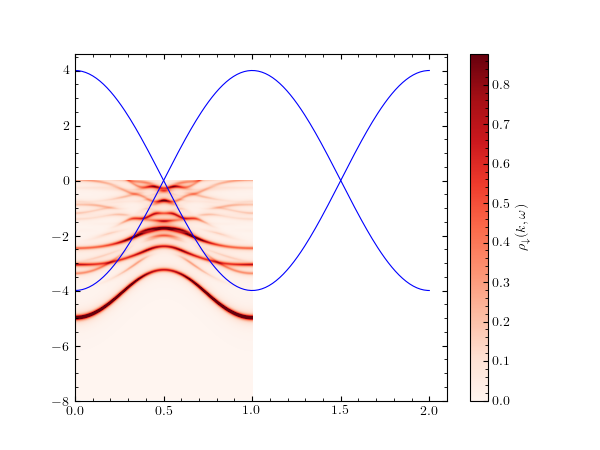

In [30]:
%matplotlib ipympl
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ipywidgets as widgets
from concurrent.futures import ProcessPoolExecutor

# ── 1. Parameter sweep over J1 ───────────────────────────────────────────────
PARAM_NAME   = 't_v'
param_values = np.linspace(1, 2, 10)   # J1 = 0.0, 0.22, 0.44, ..., 2.0

base_params = dict(
    t_c=1.0, t_v=1.0, Delta=0, J0=0.5, J1=2, s=0.5,
    gamma=1.0, U=-1, Rmax=3, M=3
)
k_values     = np.linspace(0, 2*np.pi, 200)
omega_values = np.linspace(-8, 0, 400)
eta          = 0.05
t_c = t_v    = 1.0

# ── 2. Worker ────────────────────────────────────────────────────────────────
def compute_column(args):
    k, omega_values, eta, params = args
    solver = ExcitonMagnonSolver(**params)
    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(k, w, eta=eta, R=0, m=None,
                                 source='no', Rsrc=0, msrc=0)
    return col

# ── 3. Pre-compute all 10 spectral maps ──────────────────────────────────────
all_spectral = {}

for pval in param_values:
    params = {**base_params, PARAM_NAME: pval}
    tasks  = [(k, omega_values, eta, params) for k in k_values]
    cols   = []
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
        for i, col in enumerate(ex.map(compute_column, tasks), 1):
            cols.append(col)
            if i % 20 == 0 or i == len(tasks):
                print(f"  J1={pval:.3f}  [{i}/{len(tasks)}]", end='\r')
    all_spectral[pval] = np.stack(cols, axis=1)  # (Nw, Nk)
    #print(f"{PARAM_NAME} = {pval:.3f}  ✓                    ")

# Fix colorscale across all frames
vmax_global = np.percentile(np.stack(list(all_spectral.values())), 99)
print("All done — building figure.")
PARAM_NAME   = 'tv'
# ── 4. Build figure once ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))

im = ax.imshow(all_spectral[param_values[0]],
               extent=[0, 1, omega_values[0]/t_c, omega_values[-1]/t_c],
               aspect='auto', origin='lower',
               cmap='Reds', vmin=0, vmax=vmax_global)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

ax.plot(k_values/np.pi,  4*t_c*np.cos(k_values), 'b-', lw=0.8)
ax.plot(k_values/np.pi, -4*t_c*np.cos(k_values), 'b-', lw=0.8)
ax.plot(k_values/np.pi, min_values, label="spin-polaron+hole")
ax.set_ylim(-7, 0)
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
title = ax.set_title(f'{PARAM_NAME} = {param_values[0]:.3f}')
plt.tight_layout()
plt.show()

# ── 5. Slider ─────────────────────────────────────────────────────────────────
slider = widgets.SelectionSlider(
    options=[(f'{PARAM_NAME} = {v:.3f}', v) for v in param_values],
    description=f'{PARAM_NAME}',
    layout=widgets.Layout(width='500px')
)

def update(change):
    im.set_data(all_spectral[change['new']])
    title.set_text(f'{PARAM_NAME} = {change["new"]:.3f}')
    fig.canvas.draw_idle()

# Replace the last two lines with this:
from IPython.display import display
import ipywidgets as widgets

slider.observe(update, names='value')
slider

In [ ]:
np.linspace(0, 20, 6)


In [ ]:
solver = ExcitonMagnonSolver(
    t_c=1.0, t_v=1.0, Delta = 0, J0=0.0, J1=1.9, s=0.5, gamma=1.0, U=-5,
    Rmax=2, M=40
)
A_no_05 = np.array([solver.spectral(np.pi/2+0.1, w, eta = 0.05, R=0, m=None,
                                 source='no', Rsrc=0, msrc=0)
                 for w in omegas])


plt.plot(omegas, A_no_05, label="$J0=0.1$")


plt.legend()
plt.xlabel("$\epsilon$/t")
plt.ylabel("Spectral density")
plt.vlines(-5.07,0,np.max(A_no_05), color = "g")
#plt.title("tc= 1.0, tv=1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-5")
#plt.ylim(0,0.1)
plt.xlim(-7,-4)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ============================================
# Replace this section with your actual data
# ============================================
# For demonstration, I'll create sample data
# You should replace this with your actual omegas and (A_no - A_J0_no) arrays

# Example data (replace with your actual data):
# omegas = your_omega_array
# spectral_data = A_no - A_J0_no

spectral_data = A_no_05 - A_J0_no

# ============================================
# Find all peaks (both positive and negative)
# ============================================

# Find peaks in the data
peaks, properties = find_peaks(spectral_data, height=0, prominence=0.001)

# Filter to get only POSITIVE peaks
positive_peaks = peaks[spectral_data[peaks] > 0]
positive_peak_values = spectral_data[positive_peaks]
positive_peak_positions = omegas[positive_peaks]

print(f"Found {len(positive_peaks)} positive peaks")
print(f"Peak positions (ε/t): {positive_peak_positions}")
print(f"Peak values: {positive_peak_values}")

# ============================================
# Plotting
# ============================================

fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))

# Top plot: Full data with all positive peaks marked
ax1.plot(omegas, spectral_data, 'r', label='Spectral density')
ax1.plot(positive_peak_positions, positive_peak_values, 'go', 
         markersize=2, label=f'Positive peaks ({len(positive_peaks)})')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel("$\\epsilon$/t")
ax1.set_ylabel("Spectral density")
ax1.set_title("tc=1.0, tv=1.0, J0=0.0, J1=0.05, s=0.5, gamma=1.0, U=-5")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(-7, -5)
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import linregress
from scipy.optimize import curve_fit

# ============================================
# Analysis 1: Peak position vs. index (your idea)
# ============================================

if len(positive_peaks) > 1:
    peak_indices = np.arange(len(positive_peaks))
    
    # Linear fit
    slope, intercept, r_value, p_value, std_err = linregress(peak_indices, positive_peak_positions)
    
    print("=" * 60)
    print("LINEAR FIT: Peak Position vs. Index")
    print("=" * 60)
    print(f"Fitted line: ε/t = {intercept:.6f} + {slope:.6f} × index")
    print(f"R² = {r_value**2:.6f}  (1.0 = perfect fit)")
    print(f"Standard error: {std_err:.6f}")
    print(f"Average spacing from slope: {slope:.6f}")
    print()
    
    # Predicted positions
    predicted_positions = intercept + slope * peak_indices
    residuals = positive_peak_positions - predicted_positions
    
    print(f"Max deviation from line: {np.max(np.abs(residuals)):.6f}")
    print(f"RMS deviation: {np.sqrt(np.mean(residuals**2)):.6f}")
    print()

# ============================================
# Analysis 2: Direct spacing calculation
# ============================================

if len(positive_peaks) > 1:
    spacings = np.diff(positive_peak_positions)
    
    print("=" * 60)
    print("DIRECT SPACING ANALYSIS")
    print("=" * 60)
    print(f"Individual spacings: {spacings}")
    print(f"Mean spacing: {np.mean(spacings):.6f}")
    print(f"Std deviation: {np.std(spacings):.6f}")
    print(f"Min spacing: {np.min(spacings):.6f}")
    print(f"Max spacing: {np.max(spacings):.6f}")
    print(f"Coefficient of variation: {np.std(spacings)/np.mean(spacings)*100:.2f}%")
    print()
    
    # Check if spacings are consistent (within 5% tolerance)
    tolerance = 0.05
    spacing_variation = np.std(spacings) / np.mean(spacings)
    if spacing_variation < tolerance:
        print(f"✓ Peaks are EVENLY SPACED (variation < {tolerance*100}%)")
    else:
        print(f"✗ Peaks are NOT evenly spaced (variation = {spacing_variation*100:.2f}%)")
    print()

# ============================================
# Plotting
# ============================================

plt.plot(peak_indices, positive_peak_positions, 'go', markersize=2, 
         label='Actual peaks', zorder=5)
plt.plot(peak_indices, predicted_positions, 'r--', linewidth=1, 
         label=f'Linear fit (R²={r_value**2:.4f})')


plt.legend()
plt.grid(True, alpha=0.3)
